# Concrete Crack Detection and Localization Using Deep Learning
## Final Report - Data Science Workshop

**Submitted by:** _[Nir Darmon, 206454076]_, _[Amit Glaicher, 208707877]_, _[Ella Alperovitch (Farjun), 209462530]_

**Goal:** given a concrete image patch, predict a binary mask showing exactly where the crack is.

`RGB patch -> segmentation method -> crack mask`

This report follows the full pipeline: data cleaning, a leakage-safe split, patch creation, exploratory analysis, classical and learned baselines, a U-Net, and an analysis of where each method fails.

---
## 1. Problem and goal

We solve **semantic segmentation**: every pixel is predicted as either background (`0`) or crack (`1`).

A crack-free patch therefore has an empty mask; we do not need a separate crack/no-crack classifier.

Our main question is: **can we localize cracks accurately enough to beat simple image-processing baselines?**
We measure success mainly with **Dice** and **IoU**, which compare the predicted mask with the human annotation.

---
## 2. Motivation - why this matters

Concrete carries the buildings, bridges, tunnels and dams that everything else depends on, and most of it is now decades old. Cracking is the earliest externally visible sign that something is going wrong underneath: water reaches the reinforcement, the steel corrodes and expands, and the damage accelerates. A crack found early is a maintenance job. The same crack found late is a structural repair, a closure, or worse.

**How this is done today.** An inspector visits the structure and examines it by eye, often from a rope, a lift or scaffolding. That is expensive, slow, and dangerous, and it does not scale: a highway authority responsible for thousands of bridge spans cannot inspect them all frequently. It is also **subjective** - two inspectors looking at the same wall will not record the same cracks, which makes it hard to tell whether a crack has grown since the last visit or whether the previous inspector simply drew it differently.

**Who benefits.** Infrastructure owners and municipalities, who need to rank which structures to repair with a fixed budget; inspection contractors, who could cover far more surface per day by screening drone or phone imagery automatically and sending a human only to the flagged regions; and the public, who bear the risk when a defect is missed.

**Why a mask and not a yes/no answer.** A classifier that reports "this photo contains a crack" adds little: a human still has to find it, and the answer is nearly always yes on an old structure. A **pixel mask** is what turns an image into a measurement. From a mask we can derive crack length, width and area; we can compare masks of the same wall photographed months apart to measure **growth rate**, which is the quantity that actually drives a maintenance decision; and we can show an engineer precisely which region to examine rather than an entire photograph.

That is the practical case for framing this as segmentation rather than classification, and it is why the rest of this notebook measures success with overlap metrics against a human annotation instead of classification accuracy.

---
## 3. Data

We use the **Concrete Crack Segmentation Dataset** by Ozgenel (2019), Mendeley Data V1, CC BY 4.0.

The dataset contains **458 concrete photographs and 458 manually annotated masks** in `rgb/` and `BW/`.

The commonly used 40,000-image crack dataset contains classification labels but not masks, so it cannot train our pixel-level segmentation task.

---
## 4. Setup

The notebook uses all 458 source images for cheap quality-control steps and the train/validation/test split.

The more expensive patch-level analysis and the models use the **train + validation** images, and `PATCH_STAGE_SOURCE_IMAGE_COUNT` controls how many of them. `None` means every train and validation image; a small number gives a quick smoke run of the whole notebook. Every table and figure below states how many images produced it.

**Order of the analysis:** check image-mask pairs -> split source images -> crop patches -> explore the patches -> compare baseline methods -> train U-Net -> inspect errors.

In [1]:
import copy, hashlib, json, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm      # progress bars

from skimage.feature import graycomatrix, graycoprops, hessian_matrix, hessian_matrix_eigvals
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import joblib

import cv2
import imagehash
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
from PIL import Image, ImageOps

import torch                      # imported here to avoid the OpenMP conflict described above
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42  # reproducible random operations
PATCH_SIZE_PIXELS = 256  # patch side at native resolution
MASK_BINARIZATION_THRESHOLD = 127  # threshold used to clean JPEG mask artifacts
MINIMUM_CRACK_PIXELS_PER_PATCH = 50  # fewer pixels than this counts as background
# Used only to pick patches for the example figures, never for a metric. 50
# crack pixels is 0.08% of a patch, which is enough to call a patch positive
# but not enough to be worth looking at - those are annotation slivers
# clipping a corner. The median crack patch holds about 5,000 crack pixels.
SUBSTANTIAL_CRACK_PIXELS_FOR_EXAMPLES = 2000
PERCEPTUAL_HASH_DISTANCE_THRESHOLD = 8  # near-duplicate Hamming distance
DATA_SPLIT_FRACTIONS = {"train": 0.70, "val": 0.15, "test": 0.15}
# Train + validation images used for the patch-level stages. None = all of them;
# a small number is a quick smoke run. Every dev split gets at least one image.
PATCH_STAGE_SOURCE_IMAGE_COUNT = None
NUMBER_OF_TRAINING_EPOCHS = 20  # full data: ~1,040 batches per epoch, best epoch kept
TRAINING_BATCH_SIZE = 16  # fits the 6 GB GPU at 256x256 with mixed precision
UNET_LEARNING_RATE = 1e-3
# Caching (see build_cache_path below). Each flag only takes effect when a cache
# file with matching parameters exists in outputs/; otherwise the step runs and
# writes that file. False always recomputes and overwrites the cache.
USE_CACHED_PATCH_TABLE = True  # patch table (~4 min on all images)
LOAD_TRAINED_LOGISTIC_REGRESSION = True  # pixel sampling + fit (~3 min on all images)
USE_CACHED_BASELINE_SCORES = True  # baselines scored on the val grid (~5-10 min)
LOAD_TRAINED_UNET = True  # U-Net training (~2 min per epoch on all images)

OUTPUT_DIRECTORY = Path("outputs")
OUTPUT_DIRECTORY.mkdir(exist_ok=True)


def build_cache_path(cache_name, cache_parameters, file_suffix):
    """Cache file in outputs/ whose name is a hash of every parameter that shapes it.

    Changing any parameter changes the name, so a stale cache is never reused.
    Code changes are not part of the key - delete the file after editing the code.
    """
    parameter_hash = hashlib.sha1(
        json.dumps(cache_parameters, sort_keys=True, default=str).encode()
    ).hexdigest()[:10]
    return OUTPUT_DIRECTORY / f"{cache_name}_{parameter_hash}{file_suffix}"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
# Prefer a GPU when one exists: CUDA on the Windows machine, Metal (MPS) on
# Apple Silicon. Both fall back to the CPU, so the notebook runs anywhere.
COMPUTATION_DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
sns.set_theme(style="whitegrid")
# Embed plotly.js in the notebook rather than loading it from a CDN, so the
# exported HTML still renders the interactive figure with no network access.
pio.renderers.default = "notebook"
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})
print(f"torch {torch.__version__} | device: {COMPUTATION_DEVICE}")

torch 2.13.0+cu126 | device: cuda


In [2]:
def find_concrete_crack_dataset_directory(search_directory=Path(".")):
    """Find a directory that contains both the rgb/ and BW/ dataset folders."""
    for candidate_directory in sorted(search_directory.rglob("*")):
        if not candidate_directory.is_dir():
            continue
        if (candidate_directory / "rgb").is_dir() and (candidate_directory / "BW").is_dir():
            return candidate_directory
    raise FileNotFoundError(
        "Download the dataset from https://doi.org/10.17632/jwsn7tfbrp.1 and extract it under data/"
    )


def load_oriented_rgb_image(image_file_path):
    """Load an RGB photograph after applying the EXIF orientation."""
    with Image.open(image_file_path) as opened_image:
        corrected_image = ImageOps.exif_transpose(opened_image).convert("RGB")
        return np.asarray(corrected_image)


def load_and_binarize_crack_mask(
    mask_file_path,
    binarization_threshold=MASK_BINARIZATION_THRESHOLD,
):
    """Load an annotation mask and convert it to True=crack, False=background."""
    with Image.open(mask_file_path) as opened_mask:
        grayscale_mask = np.asarray(opened_mask.convert("L"))
    return grayscale_mask > binarization_threshold


def load_downscaled_grayscale_image(
    image_file_path,
    downscale_factor=8,
    apply_exif_orientation=True,
):
    """Load a smaller grayscale copy for quick quality-control calculations."""
    opened_image = Image.open(image_file_path)
    opened_image.draft(
        "L",
        (
            opened_image.size[0] // downscale_factor,
            opened_image.size[1] // downscale_factor,
        ),
    )
    if apply_exif_orientation:
        opened_image = ImageOps.exif_transpose(opened_image)
    return np.asarray(opened_image.convert("L"))


DATASET_DIRECTORY = find_concrete_crack_dataset_directory()
print(
    f"{DATASET_DIRECTORY.as_posix()}: "
    f"{len(list((DATASET_DIRECTORY/'rgb').iterdir()))} images, "
    f"{len(list((DATASET_DIRECTORY/'BW').iterdir()))} masks"
)


data/concrete_crack_segmentation: 458 images, 458 masks


---
## 5. What is one data point?

| Level | One item | Role |
|---|---|---|
| Source image | one photograph + its mask | unit used for train/validation/test splitting |
| Patch | one **256 x 256** crop | one sample given to the models |
| Pixel | one position inside a patch | binary target: background or crack |

We crop image and mask using the same coordinates. The patch table stores paths, crop coordinates, crack statistics and a few simple appearance descriptors; it does **not** store thousands of cropped JPEG files.

---
## 6. Cleaning and quality control

Before modelling, we must make sure every RGB photograph is paired with the correct mask and that both are spatially aligned.

We pair files by **filename stem**, not by directory order, because extensions use different capitalization and image IDs are not consecutive.

In [3]:
EXIF_ORIENTATION_TAG = 274

rgb_image_path_by_filename_stem = {
    image_file_path.stem: image_file_path
    for image_file_path in (DATASET_DIRECTORY / "rgb").iterdir()
    if image_file_path.is_file()
}
mask_path_by_filename_stem = {
    mask_file_path.stem: mask_file_path
    for mask_file_path in (DATASET_DIRECTORY / "BW").iterdir()
    if mask_file_path.is_file()
}
paired_filename_stems = sorted(
    set(rgb_image_path_by_filename_stem) & set(mask_path_by_filename_stem),
    key=lambda filename_stem: (len(filename_stem), filename_stem),
)

source_image_records = []
for filename_stem in tqdm(
    paired_filename_stems,
    desc="pairing RGB images and masks",
):
    rgb_image_file_path = rgb_image_path_by_filename_stem[filename_stem]
    mask_file_path = mask_path_by_filename_stem[filename_stem]

    with Image.open(rgb_image_file_path) as opened_rgb_image:
        stored_image_size = opened_rgb_image.size
        exif_orientation_value = opened_rgb_image.getexif().get(
            EXIF_ORIENTATION_TAG
        )
        corrected_image_size = ImageOps.exif_transpose(
            opened_rgb_image
        ).size

    with Image.open(mask_file_path) as opened_mask:
        annotation_mask_size = opened_mask.size

    source_image_records.append({
        "image_id": filename_stem,
        "rgb_path": rgb_image_file_path.as_posix(),
        "mask_path": mask_file_path.as_posix(),
        "exif_orientation": exif_orientation_value,
        "fixed_w": corrected_image_size[0],
        "fixed_h": corrected_image_size[1],
        "match_raw": stored_image_size == annotation_mask_size,
        "match_fixed": corrected_image_size == annotation_mask_size,
    })

source_image_table = pd.DataFrame(source_image_records)

orphan_rgb_image_count = len(
    set(rgb_image_path_by_filename_stem) - set(mask_path_by_filename_stem)
)
orphan_mask_count = len(
    set(mask_path_by_filename_stem) - set(rgb_image_path_by_filename_stem)
)

print(
    f"pairs {len(source_image_table)} | "
    f"orphan images {orphan_rgb_image_count} | "
    f"orphan masks {orphan_mask_count}"
)
print(
    "EXIF orientation:",
    source_image_table.exif_orientation.value_counts(dropna=False).to_dict(),
)
print(
    "dimensions match BEFORE exif_transpose: "
    f"{source_image_table.match_raw.sum()}/{len(source_image_table)}"
)
print(
    "dimensions match AFTER exif_transpose: "
    f"{source_image_table.match_fixed.sum()}/{len(source_image_table)}"
)


pairing RGB images and masks:   0%|          | 0/458 [00:00<?, ?it/s]

pairs 458 | orphan images 0 | orphan masks 0
EXIF orientation: {nan: 257, 6.0: 179, 3.0: 15, 1.0: 7}
dimensions match BEFORE exif_transpose: 279/458
dimensions match AFTER exif_transpose: 458/458


**Finding 1 - EXIF orientation matters.**

Some photographs are stored with an EXIF rotation flag while the masks are already saved in their final orientation. A raw width/height check therefore misses real alignment problems.

After applying `ImageOps.exif_transpose`, all 458 image-mask pairs have matching dimensions. We also verify the alignment from image content, not only from shape.

In [4]:
def calculate_mask_alignment_score(grayscale_image, binary_crack_mask):
    """Mean darkness inside the mask minus outside. Clearly positive = aligned."""
    if binary_crack_mask.sum() == 0 or binary_crack_mask.all():
        return np.nan
    pixel_darkness = 255.0 - grayscale_image.astype(np.float32)
    return float(pixel_darkness[binary_crack_mask].mean() - pixel_darkness[~binary_crack_mask].mean())


corrected_alignment_scores, rotated_alignment_scores, uncorrected_alignment_scores = [], [], []
for source_image_row in tqdm(source_image_table.itertuples(), total=len(source_image_table),
                      desc="checking mask alignment"):
    downscaled_binary_mask = (load_downscaled_grayscale_image(source_image_row.mask_path, apply_exif_orientation=False)
                  > MASK_BINARIZATION_THRESHOLD)
    corrected_grayscale_image = load_downscaled_grayscale_image(source_image_row.rgb_path, apply_exif_orientation=True)
    uncorrected_grayscale_image = load_downscaled_grayscale_image(source_image_row.rgb_path, apply_exif_orientation=False)
    common_height = min(corrected_grayscale_image.shape[0], downscaled_binary_mask.shape[0])
    common_width = min(corrected_grayscale_image.shape[1], downscaled_binary_mask.shape[1])
    grayscale_image_crop = corrected_grayscale_image[:common_height, :common_width]
    binary_mask_crop = downscaled_binary_mask[:common_height, :common_width]
    corrected_alignment_scores.append(calculate_mask_alignment_score(grayscale_image_crop, binary_mask_crop))
    rotated_alignment_scores.append(calculate_mask_alignment_score(grayscale_image_crop, binary_mask_crop[::-1, ::-1]))
    uncorrected_alignment_scores.append(
        calculate_mask_alignment_score(uncorrected_grayscale_image, downscaled_binary_mask)
        if uncorrected_grayscale_image.shape == downscaled_binary_mask.shape else np.nan)
source_image_table["align_fixed"] = corrected_alignment_scores
source_image_table["align_unfixed"] = uncorrected_alignment_scores

number_of_correctly_aligned_images = int((np.array(corrected_alignment_scores) > np.array(rotated_alignment_scores)).sum())
print(f"correct orientation beats 180-rotated on {number_of_correctly_aligned_images}/{len(source_image_table)} images")
print(f"mean score: correct {np.nanmean(corrected_alignment_scores):.1f} vs "
      f"rotated {np.nanmean(rotated_alignment_scores):.1f}")
images_with_180_degree_rotation = source_image_table[source_image_table.exif_orientation == 3]
print(f"\nthe {len(images_with_180_degree_rotation)} 'rotate 180' images, invisible to a shape check:")
print(f"  dimensions matched without the fix "
      f"{images_with_180_degree_rotation.match_raw.sum()}/{len(images_with_180_degree_rotation)} | "
      f"alignment WITH fix {images_with_180_degree_rotation.align_fixed.mean():.1f}, "
      f"WITHOUT {images_with_180_degree_rotation.align_unfixed.mean():.1f}")

checking mask alignment:   0%|          | 0/458 [00:00<?, ?it/s]

correct orientation beats 180-rotated on 458/458 images
mean score: correct 68.1 vs rotated 4.9

the 15 'rotate 180' images, invisible to a shape check:
  dimensions matched without the fix 15/15 | alignment WITH fix 70.5, WITHOUT 6.0


The content check confirms that the corrected orientation matches the masks far better than a 180-degree-rotated alternative.

This is an important data-cleaning result: **a pair can have identical dimensions and still be misaligned**. From this point onward every RGB image is loaded through `load_oriented_rgb_image()`.

checking mask values:   0%|          | 0/458 [00:00<?, ?it/s]

,pixel type,percent
0,black (background),98.376%
1,gray (JPEG artifacts),0.519%
2,white (crack),1.104%


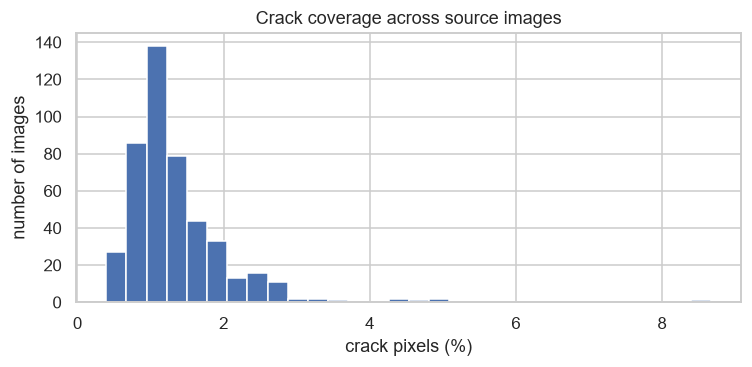

Mean crack coverage: 1.36% | empty source masks: 0


In [5]:
mask_pixel_value_histogram = np.zeros(256, dtype=np.int64)
crack_pixel_count_per_source_image = []

for mask_file_path in tqdm(source_image_table.mask_path, desc="checking mask values"):
    with Image.open(mask_file_path) as opened_mask:
        grayscale_mask_values = np.asarray(opened_mask.convert("L"))
    mask_pixel_value_histogram += np.bincount(
        grayscale_mask_values.ravel(), minlength=256
    )
    crack_pixel_count_per_source_image.append(
        int((grayscale_mask_values > MASK_BINARIZATION_THRESHOLD).sum())
    )

source_image_table["crack_pixels"] = crack_pixel_count_per_source_image
source_image_table["crack_ratio"] = (
    source_image_table["crack_pixels"]
    / (source_image_table.fixed_w * source_image_table.fixed_h)
)

total_mask_pixel_count = mask_pixel_value_histogram.sum()
mask_pixel_value_summary = pd.DataFrame({
    "pixel type": ["black (background)", "gray (JPEG artifacts)", "white (crack)"],
    "percent": [
        100 * mask_pixel_value_histogram[0] / total_mask_pixel_count,
        100 * mask_pixel_value_histogram[1:255].sum() / total_mask_pixel_count,
        100 * mask_pixel_value_histogram[255] / total_mask_pixel_count,
    ],
})

display(mask_pixel_value_summary.style.format({"percent": "{:.3f}%"}))

crack_coverage_figure, crack_coverage_axis = plt.subplots(figsize=(7, 3.5))
crack_coverage_axis.hist(100 * source_image_table.crack_ratio, bins=30)
crack_coverage_axis.set_title("Crack coverage across source images")
crack_coverage_axis.set_xlabel("crack pixels (%)")
crack_coverage_axis.set_ylabel("number of images")
plt.show()

print(
    f"Mean crack coverage: {100 * source_image_table.crack_ratio.mean():.2f}% | "
    f"empty source masks: {(source_image_table['crack_pixels'] == 0).sum()}"
)


**Finding 2 - the masks are not perfectly binary.**

JPEG compression creates intermediate gray values around crack boundaries. We therefore convert every mask to grayscale and apply one fixed threshold (`127`) to obtain a clean binary target.

The masks also show strong pixel imbalance: only a small fraction of pixels belong to cracks. This is why ordinary pixel accuracy will later be misleading.

---
## 7. Split the source images before cropping

Patches cut from the same photograph are highly related, so they must never be divided between training and evaluation.

We first group near-duplicate source photographs with a perceptual hash, then assign whole groups to **70% train, 15% validation and 15% test** while keeping crack coverage similar.

The split is frozen in `outputs/split.csv`; the test images are touched only once, for the final evaluation.

In [6]:
def group_near_duplicate_source_images(source_image_paths, maximum_hamming_distance):
    """Group source images whose perceptual hashes are very similar."""
    perceptual_hash_bits = np.array([
        imagehash.phash(
            Image.fromarray(load_downscaled_grayscale_image(source_image_path))
        ).hash.ravel()
        for source_image_path in tqdm(source_image_paths, desc="perceptual hashing")
    ]).astype(np.int8)

    pairwise_hamming_distances = (
        perceptual_hash_bits[:, None, :] != perceptual_hash_bits[None, :, :]
    ).sum(-1)

    parent_image_index = list(range(len(pairwise_hamming_distances)))

    def find_duplicate_group_root(image_index):
        while parent_image_index[image_index] != image_index:
            parent_image_index[image_index] = parent_image_index[
                parent_image_index[image_index]
            ]
            image_index = parent_image_index[image_index]
        return image_index

    near_duplicate_pairs = zip(*np.where(
        np.triu(
            pairwise_hamming_distances <= maximum_hamming_distance,
            k=1,
        )
    ))

    for first_image_index, second_image_index in near_duplicate_pairs:
        first_group_root = find_duplicate_group_root(int(first_image_index))
        second_group_root = find_duplicate_group_root(int(second_image_index))
        if first_group_root != second_group_root:
            parent_image_index[second_group_root] = first_group_root

    duplicate_group_roots = [
        find_duplicate_group_root(image_index)
        for image_index in range(len(pairwise_hamming_distances))
    ]
    duplicate_group_id_by_root = {
        group_root: duplicate_group_id
        for duplicate_group_id, group_root in enumerate(
            sorted(set(duplicate_group_roots))
        )
    }
    return np.array([
        duplicate_group_id_by_root[group_root]
        for group_root in duplicate_group_roots
    ])


def assign_duplicate_groups_to_data_splits(
    source_image_dataframe,
    split_fractions,
    random_seed=RANDOM_SEED,
):
    """Assign whole duplicate groups while keeping crack coverage similar across splits."""
    random_generator = np.random.default_rng(random_seed)
    assigned_image_count_by_split = {
        split_name: 0 for split_name in split_fractions
    }
    image_count_by_duplicate_group = source_image_dataframe.groupby("dup_group").size()
    stratum_by_duplicate_group = (
        source_image_dataframe.groupby("dup_group").stratum.first()
    )
    split_name_by_duplicate_group = {}

    for crack_ratio_stratum in sorted(source_image_dataframe.stratum.unique()):
        duplicate_groups_in_stratum = stratum_by_duplicate_group[
            stratum_by_duplicate_group == crack_ratio_stratum
        ].index.values

        for duplicate_group_id in random_generator.permutation(
            duplicate_groups_in_stratum
        ):
            number_of_images_already_assigned = max(
                sum(assigned_image_count_by_split.values()), 1
            )
            selected_split_name = max(
                split_fractions,
                key=lambda candidate_split_name: (
                    split_fractions[candidate_split_name]
                    - assigned_image_count_by_split[candidate_split_name]
                    / number_of_images_already_assigned
                ),
            )
            split_name_by_duplicate_group[duplicate_group_id] = selected_split_name
            assigned_image_count_by_split[selected_split_name] += int(
                image_count_by_duplicate_group[duplicate_group_id]
            )

    return split_name_by_duplicate_group


source_image_table["dup_group"] = group_near_duplicate_source_images(
    source_image_table.rgb_path,
    PERCEPTUAL_HASH_DISTANCE_THRESHOLD,
)
source_image_table["stratum"] = pd.qcut(
    source_image_table.crack_ratio,
    4,
    labels=False,
)
source_image_table["split"] = source_image_table.dup_group.map(
    assign_duplicate_groups_to_data_splits(
        source_image_table,
        DATA_SPLIT_FRACTIONS,
    )
)

data_split_summary = (
    source_image_table.groupby("split")
    .agg(
        images=("image_id", "size"),
        mean_crack_pct=(
            "crack_ratio",
            lambda crack_ratios: 100 * crack_ratios.mean(),
        ),
    )
    .reindex(["train", "val", "test"])
)
display(data_split_summary.style.format({"mean_crack_pct": "{:.2f}%"}))

image_ids_by_split = {
    split_name: set(
        source_image_table.loc[
            source_image_table.split == split_name,
            "image_id",
        ]
    )
    for split_name in DATA_SPLIT_FRACTIONS
}
duplicate_groups_by_split = {
    split_name: set(
        source_image_table.loc[
            source_image_table.split == split_name,
            "dup_group",
        ]
    )
    for split_name in DATA_SPLIT_FRACTIONS
}

for first_split_name in image_ids_by_split:
    for second_split_name in image_ids_by_split:
        if first_split_name < second_split_name:
            assert not (
                image_ids_by_split[first_split_name]
                & image_ids_by_split[second_split_name]
            ), f"image leak {first_split_name}/{second_split_name}"
            assert not (
                duplicate_groups_by_split[first_split_name]
                & duplicate_groups_by_split[second_split_name]
            ), f"duplicate-group leak {first_split_name}/{second_split_name}"

print("PASS: image ids and duplicate groups are disjoint across splits")

frozen_split_path = OUTPUT_DIRECTORY / "split.csv"
if frozen_split_path.exists():
    frozen_split_by_image_id = pd.read_csv(
        frozen_split_path, dtype={"image_id": str}
    ).set_index("image_id")["split"]
    assert source_image_table.set_index("image_id")["split"].equals(
        frozen_split_by_image_id.reindex(source_image_table.image_id)
    ), "recomputed split differs from the frozen outputs/split.csv"
    print(f"PASS: split matches the frozen {frozen_split_path.as_posix()}")
else:
    source_image_table.to_csv(frozen_split_path, index=False)
    print(f"split frozen to {frozen_split_path.as_posix()}")


perceptual hashing:   0%|          | 0/458 [00:00<?, ?it/s]

,images,mean_crack_pct
split,,
train,320,1.38%
val,69,1.26%
test,69,1.34%


PASS: image ids and duplicate groups are disjoint across splits
PASS: split matches the frozen outputs/split.csv


The table checks that the three splits contain similar average crack coverage, while the assertions verify that neither image IDs nor near-duplicate groups cross split boundaries.

The assignment is frozen in `outputs/split.csv`: if the file exists, the recomputed split must match it exactly, so every run uses the same split. **All development - EDA, tuning and model selection - uses only train and validation.**

---
## 8. Create 256 x 256 patches

The original photographs are large, while the models need fixed-size inputs. We therefore **crop** non-overlapping `256 x 256` patches instead of resizing the full image.

Cropping preserves thin cracks that could disappear during aggressive downscaling. Image and mask always use the same crop coordinates.

Patches are cut from **train and validation source images only**; the held-out test images remain untouched.

creating patch table:   0%|          | 0/389 [00:00<?, ?it/s]

,patches,crack_containing_patches,crack_patch_pct,empty_patches
split,,,,
train,52059,8315,16.0%,43744
val,11271,1815,16.1%,9456


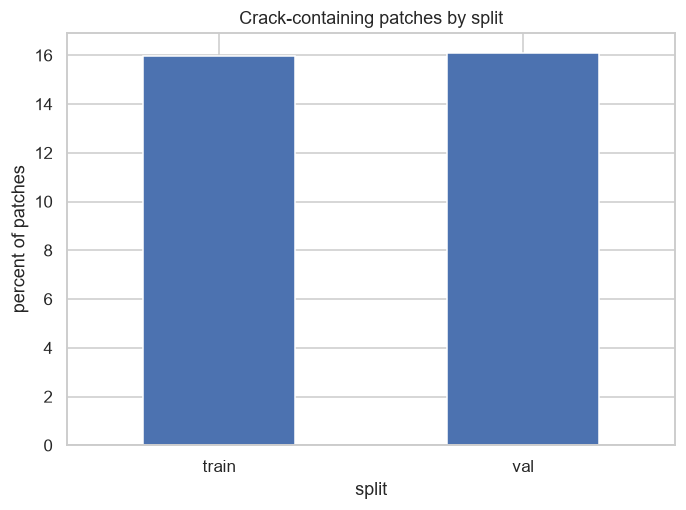

63,330 patches from 389 source images (320 train + 69 val) in 247s | 83.6% completely empty


In [7]:
def calculate_patch_appearance_descriptors(rgb_image_patch):
    """Calculate simple patch-level descriptors used only for exploratory analysis."""
    grayscale_patch = cv2.cvtColor(rgb_image_patch, cv2.COLOR_RGB2GRAY)
    grayscale_float_values = grayscale_patch.astype(np.float32)
    fifth_percentile, ninety_fifth_percentile = np.percentile(grayscale_float_values, [5, 95])
    quantized_grayscale_patch = (cv2.resize(grayscale_patch, (64, 64), interpolation=cv2.INTER_AREA)
                 // 32).astype(np.uint8)
    gray_level_cooccurrence_matrix = graycomatrix(quantized_grayscale_patch, [1], [0, np.pi / 2], levels=8,
                        symmetric=True, normed=True)
    return dict(gray_mean=float(grayscale_float_values.mean()), gray_std=float(grayscale_float_values.std()),
                dyn_range=float(ninety_fifth_percentile - fifth_percentile),
                edge_density=float((cv2.Canny(grayscale_patch, 50, 150) > 0).mean()),
                lap_var=float(cv2.Laplacian(grayscale_patch, cv2.CV_32F).var()),
                sat_mean=float(cv2.cvtColor(rgb_image_patch,
                                            cv2.COLOR_RGB2HSV)[:, :, 1].mean()),
                glcm_contrast=float(graycoprops(gray_level_cooccurrence_matrix, "contrast").mean()))


def create_patch_records_for_source_image(source_image_row, patch_size=PATCH_SIZE_PIXELS):
    """One record per grid patch of a source image, with its crack statistics."""
    full_rgb_image = load_oriented_rgb_image(source_image_row.rgb_path)
    full_binary_mask = load_and_binarize_crack_mask(source_image_row.mask_path)
    assert full_rgb_image.shape[:2] == full_binary_mask.shape, f"{source_image_row.image_id}: shape mismatch"
    image_height, image_width = full_binary_mask.shape
    patch_top_left_coordinates = [(patch_top_coordinate, patch_left_coordinate) for patch_top_coordinate in range(0, image_height - patch_size + 1, patch_size)
               for patch_left_coordinate in range(0, image_width - patch_size + 1, patch_size)]
    patch_records = []
    for patch_index, (patch_top_coordinate, patch_left_coordinate) in enumerate(patch_top_left_coordinates):
        patch_row_slice = slice(
            patch_top_coordinate, patch_top_coordinate + patch_size
        )
        patch_column_slice = slice(
            patch_left_coordinate, patch_left_coordinate + patch_size
        )
        binary_mask_patch = full_binary_mask[patch_row_slice, patch_column_slice]                     # identical coordinates
        number_of_crack_pixels = int(binary_mask_patch.sum())
        patch_record = dict(image_id=source_image_row.image_id, split=source_image_row.split,
                      patch_id=patch_index, y0=patch_top_coordinate, x0=patch_left_coordinate, size=patch_size,
                      crack_pixels=number_of_crack_pixels,
                      crack_ratio=number_of_crack_pixels / patch_size ** 2,
                      has_crack=number_of_crack_pixels >= MINIMUM_CRACK_PIXELS_PER_PATCH)
        patch_record.update(calculate_patch_appearance_descriptors(full_rgb_image[patch_row_slice, patch_column_slice]))
        patch_records.append(patch_record)
    return patch_records


subset_sampling_random_generator = np.random.default_rng(RANDOM_SEED)

# Patch images come only from train + validation; the test split stays untouched.
development_split_fraction = DATA_SPLIT_FRACTIONS["train"] + DATA_SPLIT_FRACTIONS["val"]
if PATCH_STAGE_SOURCE_IMAGE_COUNT is None:
    patch_stage_source_image_counts_by_split = {
        split_name: int((source_image_table.split == split_name).sum())
        for split_name in ["train", "val"]
    }
else:
    number_of_training_subset_images = max(1, round(
        PATCH_STAGE_SOURCE_IMAGE_COUNT * DATA_SPLIT_FRACTIONS["train"] / development_split_fraction
    ))
    patch_stage_source_image_counts_by_split = {
        "train": number_of_training_subset_images,
        # Validation can never be empty: every model is scored on it.
        "val": max(1, PATCH_STAGE_SOURCE_IMAGE_COUNT - number_of_training_subset_images),
    }

patch_stage_source_image_ids = []
for split_name, number_of_source_images_to_sample in patch_stage_source_image_counts_by_split.items():
    source_image_ids_in_split = source_image_table.loc[
        source_image_table.split == split_name, "image_id"
    ].values
    patch_stage_source_image_ids.extend(
        subset_sampling_random_generator.choice(
            source_image_ids_in_split,
            size=min(number_of_source_images_to_sample, len(source_image_ids_in_split)),
            replace=False,
        )
    )

patch_stage_source_image_table = source_image_table[source_image_table.image_id.isin(patch_stage_source_image_ids)]

patch_table_cache_path = build_cache_path(
    "patch_index",
    {
        "source_image_ids": sorted(patch_stage_source_image_ids),
        "patch_size": PATCH_SIZE_PIXELS,
        "mask_threshold": MASK_BINARIZATION_THRESHOLD,
        "minimum_crack_pixels": MINIMUM_CRACK_PIXELS_PER_PATCH,
    },
    ".parquet",
)

calculation_start_time = time.time()
if USE_CACHED_PATCH_TABLE and patch_table_cache_path.exists():
    patch_metadata_table = pd.read_parquet(patch_table_cache_path)
    patch_table_origin = f"loaded from cache {patch_table_cache_path.as_posix()}"
else:
    patch_metadata_table = pd.DataFrame([
        patch_record
        for source_image_row in tqdm(
            patch_stage_source_image_table.itertuples(),
            total=len(patch_stage_source_image_table),
            desc="creating patch table",
        )
        for patch_record in create_patch_records_for_source_image(source_image_row)
    ])
    patch_metadata_table.to_parquet(patch_table_cache_path, index=False)
    patch_table_origin = f"computed and cached to {patch_table_cache_path.as_posix()}"

patch_split_summary = (
    patch_metadata_table.groupby("split")
    .agg(
        patches=("patch_id", "size"),
        crack_containing_patches=("has_crack", "sum"),
        crack_patch_pct=("has_crack", lambda crack_flags: 100 * crack_flags.mean()),
    )
    .reindex(["train", "val"])
)
patch_split_summary["empty_patches"] = (
    patch_split_summary["patches"] - patch_split_summary["crack_containing_patches"]
)

display(
    patch_split_summary.style.format({"crack_patch_pct": "{:.1f}%"})
)

patch_split_summary["crack_patch_pct"].plot.bar(
    title="Crack-containing patches by split",
    ylabel="percent of patches",
    rot=0,
)
plt.show()

print(
    f"{len(patch_metadata_table):,} patches from {len(patch_stage_source_image_table)} source images "
    f"({patch_stage_source_image_counts_by_split['train']} train + "
    f"{patch_stage_source_image_counts_by_split['val']} val) "
    f"in {time.time()-calculation_start_time:.0f}s | "
    f"{100*(patch_metadata_table.crack_pixels == 0).mean():.1f}% completely empty"
)
print(patch_table_origin)


Most cropped patches contain no crack at all. That is expected: every **source photograph** contains a crack, but the crack occupies only a small part of the large image.

This imbalance affects training and evaluation:

- **Training:** keep all crack patches and sample a similar number of empty patches.
- **Validation:** keep the complete grid so the score reflects the real distribution.

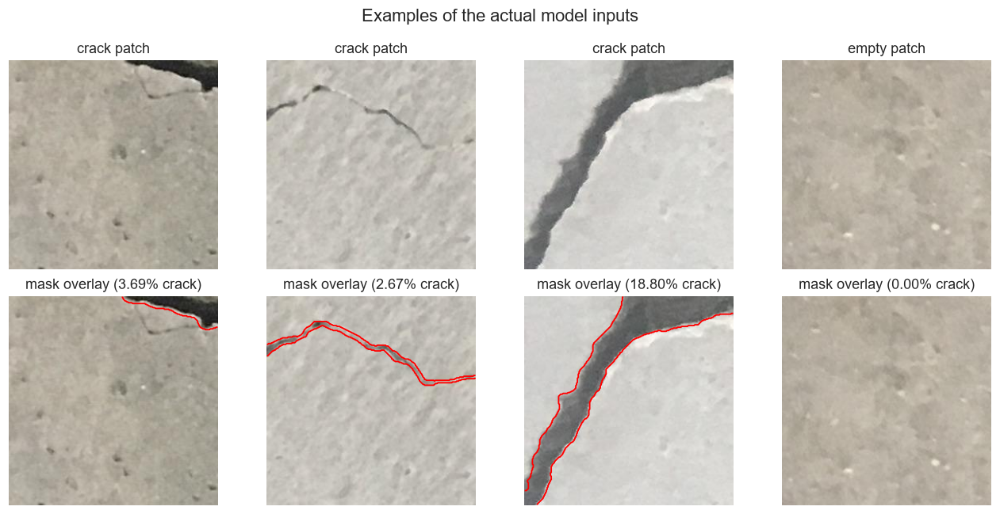

In [8]:
source_paths_by_image_id = source_image_table.set_index("image_id")[["rgb_path", "mask_path"]]

crack_patch_examples = patch_metadata_table[patch_metadata_table.has_crack].sample(3, random_state=RANDOM_SEED)
empty_patch_example = patch_metadata_table[~patch_metadata_table.has_crack].sample(1, random_state=RANDOM_SEED)
example_patch_rows = pd.concat([crack_patch_examples, empty_patch_example]).reset_index(drop=True)

patch_example_figure, patch_example_axes = plt.subplots(2, 4, figsize=(12, 6))

for example_column_index, patch_metadata_row in enumerate(example_patch_rows.itertuples()):
    source_image_paths = source_paths_by_image_id.loc[patch_metadata_row.image_id]
    patch_row_slice = slice(patch_metadata_row.y0, patch_metadata_row.y0 + patch_metadata_row.size)
    patch_column_slice = slice(patch_metadata_row.x0, patch_metadata_row.x0 + patch_metadata_row.size)

    rgb_image_patch = load_oriented_rgb_image(source_image_paths.rgb_path)[patch_row_slice, patch_column_slice]
    binary_mask_patch = load_and_binarize_crack_mask(source_image_paths.mask_path)[patch_row_slice, patch_column_slice]

    patch_example_axes[0, example_column_index].imshow(rgb_image_patch)
    patch_example_axes[0, example_column_index].set_title(
        "crack patch" if patch_metadata_row.has_crack else "empty patch"
    )

    patch_example_axes[1, example_column_index].imshow(rgb_image_patch)
    if binary_mask_patch.any():
        patch_example_axes[1, example_column_index].contour(
            binary_mask_patch.astype(float), [0.5], colors="red", linewidths=1.2
        )
    patch_example_axes[1, example_column_index].set_title(
        f"mask overlay ({100*patch_metadata_row.crack_ratio:.2f}% crack)"
    )

    patch_example_axes[0, example_column_index].axis("off")
    patch_example_axes[1, example_column_index].axis("off")

patch_example_figure.suptitle("Examples of the actual model inputs")
plt.show()


These examples are the most important visual sanity check: the red annotation should lie on the visible crack, and an empty patch should have no contour.

At this point we know the files are paired correctly, orientation is fixed, masks are binary and the crop coordinates are aligned.

---
## 9. EDA - can simple appearance features explain the cracks?

Before training models, we summarize each **training patch** with a few simple descriptors such as brightness, contrast, edge density and texture.

We use them only to understand the dataset; they are **not inputs to the U-Net**.

Two questions guide this section:

1. Which descriptors are related to crack coverage?
2. Do the patches naturally separate into clear visual groups?

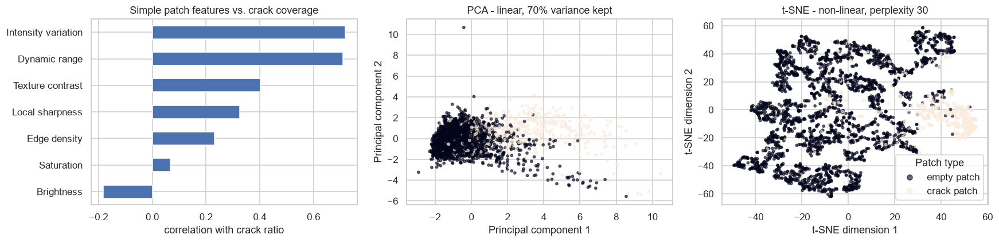

In [9]:
PATCH_DESCRIPTOR_COLUMNS = [
    "gray_mean",
    "gray_std",
    "dyn_range",
    "edge_density",
    "lap_var",
    "sat_mean",
    "glcm_contrast",
]

PATCH_DESCRIPTOR_DISPLAY_NAMES = {
    "gray_mean": "Brightness",
    "gray_std": "Intensity variation",
    "dyn_range": "Dynamic range",
    "edge_density": "Edge density",
    "lap_var": "Local sharpness",
    "sat_mean": "Saturation",
    "glcm_contrast": "Texture contrast",
}

training_patch_metadata_for_eda = patch_metadata_table[
    patch_metadata_table.split == "train"
].copy()
sampled_training_patches_for_eda = training_patch_metadata_for_eda.sample(
    min(3000, len(training_patch_metadata_for_eda)),
    random_state=RANDOM_SEED,
).reset_index(drop=True)

patch_descriptor_standardizer = StandardScaler()
standardized_patch_descriptor_matrix = patch_descriptor_standardizer.fit_transform(
    sampled_training_patches_for_eda[PATCH_DESCRIPTOR_COLUMNS]
)

principal_component_analysis_model = PCA(
    n_components=2,
    random_state=RANDOM_SEED,
)
two_dimensional_pca_coordinates = principal_component_analysis_model.fit_transform(
    standardized_patch_descriptor_matrix
)

# t-SNE is compared against PCA because the two answer different questions.
# PCA is linear and preserves global variance directions; t-SNE is non-linear
# and preserves local neighbourhoods, so it can expose groups that PCA folds
# on top of each other.
#
# perplexity controls how many neighbours each point is fitted against. The
# useful range is roughly 5-50; we take 30, the middle of that range, which
# suits a few thousand points. Much lower fragments the map into noise, much
# higher blurs local structure back into a PCA-like picture.
t_distributed_stochastic_neighbour_model = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=RANDOM_SEED,
)
two_dimensional_tsne_coordinates = (
    t_distributed_stochastic_neighbour_model.fit_transform(
        standardized_patch_descriptor_matrix
    )
)

descriptor_correlation_with_crack_ratio = (
    training_patch_metadata_for_eda[PATCH_DESCRIPTOR_COLUMNS + ["crack_ratio"]]
    .corr()["crack_ratio"]
    .drop("crack_ratio")
    .sort_values()
)
descriptor_correlation_for_display = descriptor_correlation_with_crack_ratio.rename(
    index=PATCH_DESCRIPTOR_DISPLAY_NAMES
)

eda_figure, eda_axes = plt.subplots(1, 3, figsize=(16, 4))

descriptor_correlation_for_display.plot.barh(ax=eda_axes[0])
eda_axes[0].set_title(
    "Simple patch features vs. crack coverage\n"
    f"(all {len(training_patch_metadata_for_eda):,} train patches)"
)
eda_axes[0].set_xlabel("correlation with crack ratio")

patch_type_colour_labels = sampled_training_patches_for_eda["has_crack"].astype(int)

low_dimensional_views = [
    (
        eda_axes[1],
        two_dimensional_pca_coordinates,
        "PCA - linear, "
        f"{100 * principal_component_analysis_model.explained_variance_ratio_.sum():.0f}% variance kept\n"
        f"({len(sampled_training_patches_for_eda):,} sampled train patches)",
        "Principal component",
    ),
    (
        eda_axes[2],
        two_dimensional_tsne_coordinates,
        "t-SNE - non-linear, perplexity 30\n"
        f"({len(sampled_training_patches_for_eda):,} sampled train patches)",
        "t-SNE dimension",
    ),
]

for plot_axis, embedding_coordinates, panel_title, axis_label in low_dimensional_views:
    embedding_scatter_plot = plot_axis.scatter(
        embedding_coordinates[:, 0],
        embedding_coordinates[:, 1],
        c=patch_type_colour_labels,
        s=8,
        alpha=0.6,
    )
    plot_axis.set_title(panel_title)
    plot_axis.set_xlabel(f"{axis_label} 1")
    plot_axis.set_ylabel(f"{axis_label} 2")

embedding_legend_handles, _ = embedding_scatter_plot.legend_elements()
eda_axes[2].legend(
    embedding_legend_handles,
    ["empty patch", "crack patch"],
    title="Patch type",
)

plt.show()

**The descriptors separate the two patch types better than expected** - and that turns out to be the wrong kind of success.

Intensity variation and dynamic range both correlate with crack coverage at about **r = 0.70**, and in both embeddings the crack patches occupy a recognisable region rather than scattering at random: a tail extending right in PCA, a concentration on the right-hand side in t-SNE. This is not a null result.

**PCA against t-SNE.** The two are shown side by side because they answer different questions. PCA is a linear rotation onto the directions of greatest variance, so it keeps global distances meaningful but can only separate groups along straight boundaries. t-SNE optimises a non-linear map that preserves each point's neighbourhood, so it exposes structure PCA folds flat - at the cost of global distances, which is why its axes carry no units and why cluster *sizes* and *separations* in a t-SNE plot must never be read quantitatively. Here they agree, which is the useful outcome: the structure PCA shows is real and not an artefact of forcing a linear projection.

**Why this does not solve the problem.** Every descriptor is one number summarising a whole 256 x 256 patch. Together they answer "does this patch probably contain a crack?" reasonably well - but that is *detection*, and our task is *localisation*. No amount of patch-level brightness or texture statistics can say which of the 65,536 pixels belongs to the crack, and a patch-level answer cannot be scored with Dice at all.

That distinction is the reason this project is framed as segmentation, and the reason the models in the next chapter all take the raw pixels as input rather than these seven numbers.

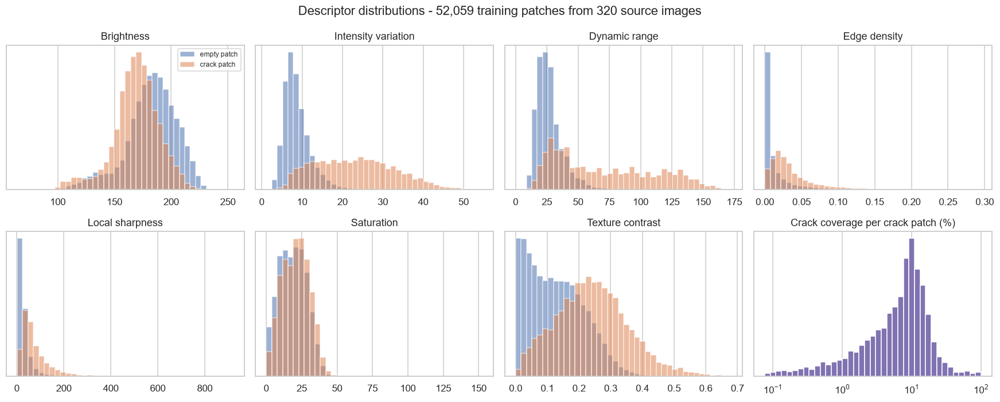

,standardised mean difference
Intensity variation,+1.98
Dynamic range,+1.77
Texture contrast,+1.14
Local sharpness,+1.00
Edge density,+0.69
Brightness,-0.57
Saturation,+0.22


In [10]:
# Descriptor distributions, split by whether the patch contains a crack.
# The PCA and t-SNE views above compress seven descriptors into two axes; these
# histograms show each descriptor on its own, which is what tells us *which*
# descriptor carries the separation and which is pure overlap.
crack_containing_training_patches = training_patch_metadata_for_eda[
    training_patch_metadata_for_eda.has_crack
]
empty_training_patches = training_patch_metadata_for_eda[
    ~training_patch_metadata_for_eda.has_crack
]

distribution_figure, distribution_axes = plt.subplots(2, 4, figsize=(16, 6.5))
flattened_distribution_axes = distribution_axes.ravel()

for descriptor_axis, descriptor_column in zip(
    flattened_distribution_axes,
    PATCH_DESCRIPTOR_COLUMNS,
):
    shared_histogram_bins = np.histogram_bin_edges(
        training_patch_metadata_for_eda[descriptor_column],
        bins=40,
    )
    for patch_group, group_label in [
        (empty_training_patches, "empty patch"),
        (crack_containing_training_patches, "crack patch"),
    ]:
        descriptor_axis.hist(
            patch_group[descriptor_column],
            bins=shared_histogram_bins,
            density=True,
            alpha=0.55,
            label=group_label,
        )
    descriptor_axis.set_title(PATCH_DESCRIPTOR_DISPLAY_NAMES[descriptor_column])
    descriptor_axis.set_yticks([])

# The eighth panel is the target itself rather than a descriptor: how much of a
# patch is crack, given that it contains one at all.
crack_coverage_percentages = 100 * crack_containing_training_patches["crack_ratio"]
flattened_distribution_axes[7].hist(
    crack_coverage_percentages,
    bins=np.logspace(
        np.log10(max(crack_coverage_percentages.min(), 1e-3)),
        np.log10(crack_coverage_percentages.max()),
        40,
    ),
    color="#8172B2",
)
flattened_distribution_axes[7].set_xscale("log")
flattened_distribution_axes[7].set_title("Crack coverage per crack patch (%)")
flattened_distribution_axes[7].set_yticks([])

flattened_distribution_axes[0].legend(fontsize=8)
distribution_figure.suptitle(
    f"Descriptor distributions - {len(training_patch_metadata_for_eda):,} training patches "
    f"from {training_patch_metadata_for_eda.image_id.nunique()} source images"
)
plt.show()

# Quantify the visual impression with the standardised difference of means, so
# "which descriptor separates best" is a number and not an eyeball judgement.
descriptor_separation_strength = pd.Series(
    {
        PATCH_DESCRIPTOR_DISPLAY_NAMES[descriptor_column]: (
            crack_containing_training_patches[descriptor_column].mean()
            - empty_training_patches[descriptor_column].mean()
        )
        / training_patch_metadata_for_eda[descriptor_column].std()
        for descriptor_column in PATCH_DESCRIPTOR_COLUMNS
    }
).sort_values(key=np.abs, ascending=False)
display(
    descriptor_separation_strength.rename("standardised mean difference")
    .to_frame()
    .style.format("{:+.2f}")
)

Each descriptor is drawn as a density so the two groups stay comparable even though empty patches outnumber crack patches roughly five to one (8,028 training patches, 1,400 of them containing a crack).

**Four descriptors separate strongly.** The standardised mean differences make it concrete: intensity variation shifts by **+1.90 standard deviations**, dynamic range by **+1.68**, texture contrast by **+1.13** and local sharpness by **+1.05**. The histograms show why - empty patches pile up against the low end of intensity variation while crack patches spread across a long tail. Brightness moves the other way (**-0.78**): a crack is dark, so a patch containing one is on average darker. Saturation carries almost nothing (**+0.21**), which makes sense for grey concrete.

**But the overlap is still fatal for our purpose.** Even the strongest descriptor leaves the two histograms sharing most of their range, so any single threshold trades recall against precision. More importantly, these are patch-level summaries: a high intensity variation tells us a crack is probably *somewhere* in the patch, never *where*.

The eighth panel is the target rather than a descriptor. Among patches that do contain a crack, coverage has a median of **7.2%** and an interquartile range of **2.9% to 12.1%**, spanning three orders of magnitude from 0.08% to a few fully-cracked patches - which is why the axis is logarithmic. Combined with the 82.4% of patches that are completely empty, the positive class is rare both *across* patches and *within* them. That is the central difficulty of the task and the reason pixel accuracy is meaningless here.

KMeans:   0%|          | 0/5 [00:00<?, ?it/s]

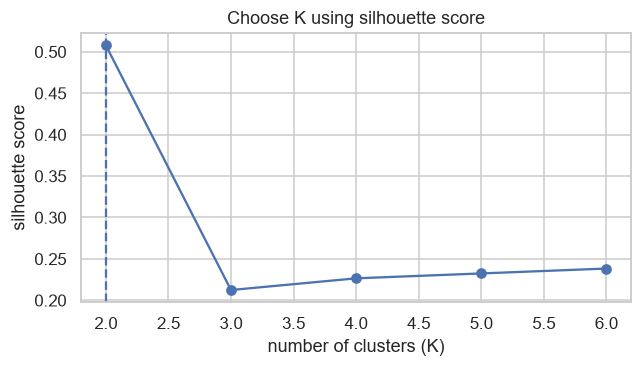

,patches,crack_patch_pct,mean_brightness,mean_texture
cluster,,,,
0,2563,7.3%,181.6,0.12
1,437,67.7%,171.4,0.30


Selected K = 2


In [11]:
silhouette_scores_by_cluster_count = []

for number_of_clusters in tqdm([2, 3, 4, 5, 6], desc="KMeans"):
    cluster_labels = KMeans(
        n_clusters=number_of_clusters,
        n_init=10,
        random_state=RANDOM_SEED,
    ).fit_predict(standardized_patch_descriptor_matrix)
    silhouette_scores_by_cluster_count.append((
        number_of_clusters,
        silhouette_score(standardized_patch_descriptor_matrix, cluster_labels),
    ))

silhouette_score_table = pd.DataFrame(
    silhouette_scores_by_cluster_count,
    columns=["number of clusters", "silhouette score"],
)
selected_number_of_clusters = int(
    silhouette_score_table.loc[
        silhouette_score_table["silhouette score"].idxmax(),
        "number of clusters",
    ]
)

sampled_training_patches_for_eda["cluster"] = KMeans(
    n_clusters=selected_number_of_clusters,
    n_init=10,
    random_state=RANDOM_SEED,
).fit_predict(standardized_patch_descriptor_matrix)
# K-Means numbers its clusters arbitrarily, so the same grouping can come out as
# 0/1 on one run and 1/0 on the next. Renumber by mean texture contrast, roughest
# first, so the text can refer to cluster 0 reliably. Uses descriptors only,
# never the crack label.
cluster_ids_by_texture = (
    sampled_training_patches_for_eda.groupby("cluster")["glcm_contrast"]
    .mean()
    .sort_values(ascending=False)
    .index
)
sampled_training_patches_for_eda["cluster"] = sampled_training_patches_for_eda[
    "cluster"
].map({old_cluster_id: new_cluster_id
       for new_cluster_id, old_cluster_id in enumerate(cluster_ids_by_texture)})

cluster_characteristics_summary = (
    sampled_training_patches_for_eda.groupby("cluster")
    .agg(
        patches=("cluster", "size"),
        crack_patch_pct=("has_crack", lambda crack_flags: 100 * crack_flags.mean()),
        mean_brightness=("gray_mean", "mean"),
        mean_texture=("glcm_contrast", "mean"),
    )
)

silhouette_figure, silhouette_axis = plt.subplots(figsize=(6, 3.5))
silhouette_axis.plot(
    silhouette_score_table["number of clusters"],
    silhouette_score_table["silhouette score"],
    marker="o",
)
silhouette_axis.set_title(
    "Choose K using silhouette score\n"
    f"({len(sampled_training_patches_for_eda):,} sampled train patches)"
)
silhouette_axis.set_xlabel("number of clusters (K)")
silhouette_axis.set_ylabel("silhouette score")
silhouette_axis.axvline(selected_number_of_clusters, linestyle="--")
plt.show()

display(
    cluster_characteristics_summary.style.format({
        "crack_patch_pct": "{:.1f}%",
        "mean_brightness": "{:.1f}",
        "mean_texture": "{:.2f}",
    })
)

print(f"Selected K = {selected_number_of_clusters}")


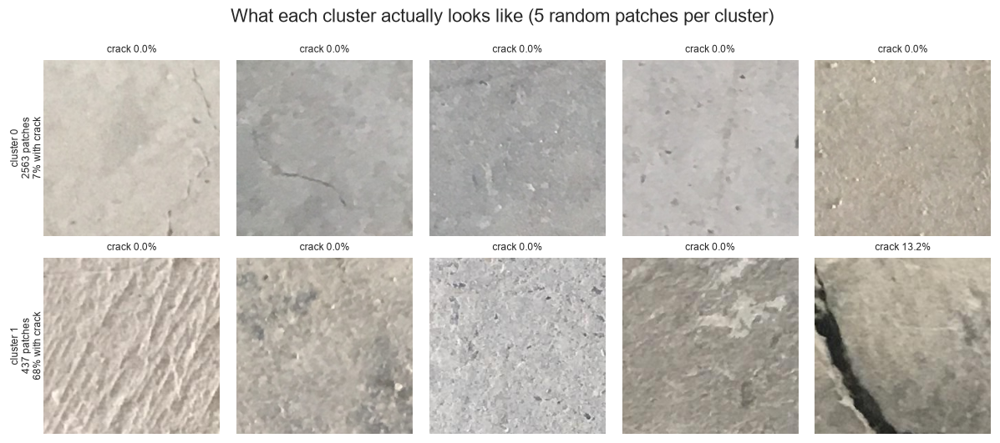

In [12]:
# The silhouette score and the summary table say the clusters differ. This shows
# what they differ *in*, which is the part a reader can actually judge: five
# random patches from each cluster, drawn with the same seed.
NUMBER_OF_CLUSTER_EXAMPLES = 5

cluster_example_figure, cluster_example_axes = plt.subplots(
    selected_number_of_clusters,
    NUMBER_OF_CLUSTER_EXAMPLES,
    figsize=(2.2 * NUMBER_OF_CLUSTER_EXAMPLES, 2.5 * selected_number_of_clusters),
)

for cluster_index in range(selected_number_of_clusters):
    cluster_patch_rows = sampled_training_patches_for_eda[
        sampled_training_patches_for_eda.cluster == cluster_index
    ]
    cluster_patch_rows = cluster_patch_rows.sample(
        min(NUMBER_OF_CLUSTER_EXAMPLES, len(cluster_patch_rows)),
        random_state=RANDOM_SEED,
    )
    for unused_axis in cluster_example_axes[cluster_index, len(cluster_patch_rows):]:
        unused_axis.axis("off")

    for example_column_index, patch_metadata_row in enumerate(
        cluster_patch_rows.itertuples()
    ):
        source_image_paths = source_paths_by_image_id.loc[patch_metadata_row.image_id]
        full_rgb_image = load_oriented_rgb_image(source_image_paths.rgb_path)
        rgb_image_patch = full_rgb_image[
            patch_metadata_row.y0:patch_metadata_row.y0 + patch_metadata_row.size,
            patch_metadata_row.x0:patch_metadata_row.x0 + patch_metadata_row.size,
        ]

        example_axis = cluster_example_axes[cluster_index, example_column_index]
        example_axis.imshow(rgb_image_patch)
        example_axis.axis("off")
        example_axis.set_title(
            f"crack {100 * patch_metadata_row.crack_ratio:.1f}%",
            fontsize=8,
        )

    cluster_summary_row = cluster_characteristics_summary.loc[cluster_index]
    cluster_example_axes[cluster_index, 0].text(
        -0.10,
        0.5,
        f"cluster {cluster_index}\n"
        f"{int(cluster_summary_row['patches'])} patches\n"
        f"{cluster_summary_row['crack_patch_pct']:.0f}% with crack",
        rotation=90,
        va="center",
        ha="center",
        transform=cluster_example_axes[cluster_index, 0].transAxes,
        fontsize=8,
    )

cluster_example_figure.suptitle(
    "What each cluster actually looks like "
    f"({NUMBER_OF_CLUSTER_EXAMPLES} random patches per cluster, from "
    f"{len(sampled_training_patches_for_eda):,} sampled train patches)"
)
plt.show()

K-Means groups patches by **visual appearance**; it never sees the crack label. The silhouette score chooses K rather than leaving it arbitrary, and it selects **K = 2** - the descriptors support a clean two-way split and nothing finer.

**The clusters do have a clear common denominator, and it is not a coincidence.** Cluster 0 holds 430 patches that are darker (mean brightness 172.6) and rougher (mean texture contrast 0.32), and **68.1% of them contain a crack**. Cluster 1 holds 2,570 patches that are brighter (185.6) and smoother (0.12), and only **8.2% contain a crack**. That is an **eight-fold difference in crack rate between two groups formed without ever looking at the masks**.

The example patches show why, and they are more honest than the table alone. Cluster 0 is dominated by patches holding a **wide, dark, high-contrast feature** - and in four of the five examples that feature simply *is* the crack. The crack itself is what drives the brightness down and the intensity variation up, so what the descriptors respond to is largely the crack's own shadow rather than some independent property of the surface. The fifth example is the informative exception: rough, streaky concrete with **0.0% crack coverage** that lands in cluster 0 anyway, which is exactly the 32% of that cluster which contains no crack. Cluster 1 is clean, evenly lit, uniform concrete, and all five examples are crack-free.

So the split is closer to a crude, unsupervised **crack detector** than to a grouping by surface condition - it fires on the strongest dark linear evidence in the patch, and it is fooled by texture that looks similar.

This answers the second question posed at the start of the chapter: yes, the patches separate into visual groups - but the grouping is a property of the **concrete**, not a localisation of the **crack**. An unsupervised split that is 68% crack in one half is a useful stratification variable; it is not a segmentation.

**How we will use this.** These two regimes are natural **evaluation strata**: reporting Dice separately on cluster 0 and cluster 1 will show whether the U-Net's advantage comes from handling difficult surfaces or merely from the easy ones being easy. A single average score hides that, and it is exactly the kind of breakdown a supervisor would ask for.

In [13]:
# The static t-SNE above shows the shape of the embedding but cannot tell you
# *which* patch a point is. This version is interactive: hover a point to read
# its source image, crack coverage and cluster, which turns the plot from a
# picture into a tool for chasing down outliers.
interactive_embedding_table = sampled_training_patches_for_eda.assign(
    tsne_dimension_1=two_dimensional_tsne_coordinates[:, 0],
    tsne_dimension_2=two_dimensional_tsne_coordinates[:, 1],
    crack_coverage_percent=lambda table: (100 * table.crack_ratio).round(2),
    cluster_label=lambda table: "cluster " + table.cluster.astype(str),
)

interactive_tsne_figure = px.scatter(
    interactive_embedding_table,
    x="tsne_dimension_1",
    y="tsne_dimension_2",
    color="cluster_label",
    size="crack_coverage_percent",
    size_max=12,
    opacity=0.7,
    hover_data={
        "image_id": True,
        "crack_coverage_percent": ":.2f",
        "gray_mean": ":.0f",
        "glcm_contrast": ":.2f",
        "tsne_dimension_1": False,
        "tsne_dimension_2": False,
        "cluster_label": False,
    },
    labels={
        "tsne_dimension_1": "t-SNE dimension 1",
        "tsne_dimension_2": "t-SNE dimension 2",
        "cluster_label": "K-Means cluster",
        "crack_coverage_percent": "crack coverage (%)",
        "gray_mean": "brightness",
        "glcm_contrast": "texture contrast",
    },
    title=(
        "Interactive t-SNE - marker size is crack coverage, colour is cluster "
        f"({len(interactive_embedding_table):,} sampled training patches)"
    ),
)
interactive_tsne_figure.update_layout(width=900, height=520, legend_title_text="")
interactive_tsne_figure.update_traces(marker=dict(line=dict(width=0)))
interactive_tsne_figure.show()

Hovering a point reports its source image, crack coverage, brightness and texture contrast, and marker size encodes crack coverage - so the largest markers are the most heavily cracked patches.

Two things are worth doing with it. First, the large markers concentrate in the cluster 0 region rather than scattering evenly, which is the same finding as the table but visible directly instead of inferred from averages. Second, hovering an isolated point tells you **which source image** it came from; several apparent outliers trace back to the same few photographs, which is a reminder of why the split had to be made on source images and duplicate groups rather than on patches.

We keep the static version above as well, deliberately. Interactive output depends on the viewer - GitHub does not render plotly at all, and nbviewer needs the embedded library to load - so the argument of the chapter never rests on a figure that might not appear for the reader.

---
## 10. How do we measure a segmentation?

For every pixel, the prediction can be correct or wrong. From those counts we use four simple metrics:

| Metric | Intuition |
|---|---|
| **Dice** | How strongly do the predicted and true crack regions overlap? |
| **IoU** | Overlap divided by the total area covered by either mask; stricter than Dice |
| **Precision** | Of the pixels predicted as crack, how many were really crack? |
| **Recall** | Of the real crack pixels, how many did we find? |

The two main overlap formulas are:

`Dice = 2TP / (2TP + FP + FN)`
`IoU  = TP / (TP + FP + FN)`

Because crack pixels are rare, **pixel accuracy is not our main metric**. A model can predict only background and still appear highly accurate.

In [14]:
def calculate_pixel_confusion_counts(predicted_mask, ground_truth_mask):
    """Count pixel-level true positives, false positives, false negatives and true negatives."""
    true_positive_count = int(np.count_nonzero(predicted_mask & ground_truth_mask))
    false_positive_count = int(np.count_nonzero(predicted_mask & ~ground_truth_mask))
    false_negative_count = int(np.count_nonzero(~predicted_mask & ground_truth_mask))
    true_negative_count = (
        predicted_mask.size
        - true_positive_count
        - false_positive_count
        - false_negative_count
    )
    return (
        true_positive_count,
        false_positive_count,
        false_negative_count,
        true_negative_count,
    )


def calculate_segmentation_metrics(
    true_positive_count,
    false_positive_count,
    false_negative_count,
):
    """Calculate Dice, IoU, precision and recall from the pixel counts."""
    if (
        true_positive_count
        + false_positive_count
        + false_negative_count
        == 0
    ):
        return dict(dice=1.0, iou=1.0, precision=1.0, recall=1.0)

    dice_score = (
        2 * true_positive_count
        / (
            2 * true_positive_count
            + false_positive_count
            + false_negative_count
        )
    )
    intersection_over_union = (
        true_positive_count
        / (
            true_positive_count
            + false_positive_count
            + false_negative_count
        )
    )
    precision_score = (
        true_positive_count / (true_positive_count + false_positive_count)
        if true_positive_count + false_positive_count
        else 0.0
    )
    recall_score = (
        true_positive_count / (true_positive_count + false_negative_count)
        if true_positive_count + false_negative_count
        else 0.0
    )

    return dict(
        dice=dice_score,
        iou=intersection_over_union,
        precision=precision_score,
        recall=recall_score,
    )


def evaluate_segmentation_predictions(prediction_pairs):
    """Evaluate a sequence of predicted masks against their ground-truth masks."""
    total_true_positive = 0
    total_false_positive = 0
    total_false_negative = 0
    total_true_negative = 0
    per_patch_metric_results = []

    for predicted_mask, ground_truth_mask in prediction_pairs:
        (
            true_positive_count,
            false_positive_count,
            false_negative_count,
            true_negative_count,
        ) = calculate_pixel_confusion_counts(predicted_mask, ground_truth_mask)

        total_true_positive += true_positive_count
        total_false_positive += false_positive_count
        total_false_negative += false_negative_count
        total_true_negative += true_negative_count

        per_patch_metric_results.append(
            calculate_segmentation_metrics(
                true_positive_count,
                false_positive_count,
                false_negative_count,
            )
        )

    micro_metrics = calculate_segmentation_metrics(
        total_true_positive,
        total_false_positive,
        total_false_negative,
    )
    evaluation_summary = {
        f"micro_{metric_name}": metric_value
        for metric_name, metric_value in micro_metrics.items()
    }
    evaluation_summary["macro_dice"] = float(np.mean([
        patch_metrics["dice"]
        for patch_metrics in per_patch_metric_results
    ]))
    evaluation_summary["pixel_accuracy"] = (
        (total_true_positive + total_true_negative)
        / (
            total_true_positive
            + total_false_positive
            + total_false_negative
            + total_true_negative
        )
    )
    # The raw counts are kept so the confusion matrices in chapter 12 reuse them
    # instead of predicting the whole validation grid a second time.
    evaluation_summary.update(
        tp=total_true_positive,
        fp=total_false_positive,
        fn=total_false_negative,
        tn=total_true_negative,
    )
    return evaluation_summary


def score_on_validation_with_cache(method_name, method_parameters, build_prediction_pairs):
    """Score one method on the validation grid, or reload the scores of an identical earlier run.

    build_prediction_pairs is a function returning the (prediction, truth) pairs,
    so nothing is predicted when the cached scores are used.
    """
    score_cache_path = build_cache_path(
        "val_scores_" + method_name.lower().replace(" ", "_").replace("-", "_"),
        {
            "patch_table": patch_table_cache_path.name,
            "method": method_name,
            **method_parameters,
        },
        ".json",
    )
    if USE_CACHED_BASELINE_SCORES and score_cache_path.exists():
        method_scores = json.loads(score_cache_path.read_text())
        print(f"{method_name}: validation scores loaded from cache {score_cache_path.as_posix()}")
    else:
        method_scores = evaluate_segmentation_predictions(build_prediction_pairs())
        score_cache_path.write_text(json.dumps(method_scores, indent=1))
        print(f"{method_name}: validation scores computed and cached to {score_cache_path.as_posix()}")
    method_scores["method"] = method_name
    return method_scores


def iterate_image_mask_patches_for_split(
    split_name,
    progress_description=None,
):
    """Yield aligned RGB and mask patches while loading each source image only once."""
    patches_for_selected_split = patch_metadata_table[
        patch_metadata_table.split == split_name
    ]

    def generate_image_mask_patch_pairs():
        for source_image_id, source_image_patch_rows in patches_for_selected_split.groupby(
            "image_id"
        ):
            source_image_paths = source_paths_by_image_id.loc[source_image_id]
            full_rgb_image = load_oriented_rgb_image(source_image_paths.rgb_path)
            full_binary_mask = load_and_binarize_crack_mask(
                source_image_paths.mask_path
            )

            for patch_metadata_row in source_image_patch_rows.itertuples():
                patch_row_slice = slice(
                    patch_metadata_row.y0,
                    patch_metadata_row.y0 + patch_metadata_row.size,
                )
                patch_column_slice = slice(
                    patch_metadata_row.x0,
                    patch_metadata_row.x0 + patch_metadata_row.size,
                )
                yield (
                    full_rgb_image[patch_row_slice, patch_column_slice],
                    full_binary_mask[patch_row_slice, patch_column_slice],
                )

    return tqdm(
        generate_image_mask_patch_pairs(),
        total=len(patches_for_selected_split),
        desc=progress_description or f"{split_name} patches",
    )


print("Metric helper functions are ready")


Metric helper functions are ready


---
## 11. Models - from simplest to strongest

All methods below solve the **same task**: produce a binary crack mask.

We compare the methods from the simplest baseline to the deep-learning model:

1. **All background:** a sanity-check baseline.
2. **Otsu:** automatically separates darker and brighter pixels.
3. **Black-hat morphology:** emphasizes thin dark structures before thresholding.
4. **Logistic Regression:** learns a crack probability for each pixel from a small hand-crafted feature set.
5. **U-Net:** learns the useful image features and spatial context directly from RGB patches.

The value of this progression is not the number of models; it is seeing **what extra capability each step adds**.

### 11.1 Classical image-processing baselines

These methods do not learn from examples.

- **A0:** predict background everywhere.
- **Otsu:** choose a brightness threshold automatically from each patch.
- **Black-hat:** first highlight thin dark structures, then threshold them.

They give us a low-complexity reference point before machine learning.

Background:   0%|          | 0/11271 [00:00<?, ?it/s]

Otsu:   0%|          | 0/11271 [00:00<?, ?it/s]

Black-hat:   0%|          | 0/11271 [00:00<?, ?it/s]

,micro_dice,micro_iou,micro_precision,micro_recall,pixel_accuracy
method,,,,,
Background,0.000,0.000,0.000,0.000,0.987
Otsu,0.046,0.023,0.024,0.680,0.618
Black-hat,0.465,0.303,0.664,0.358,0.989


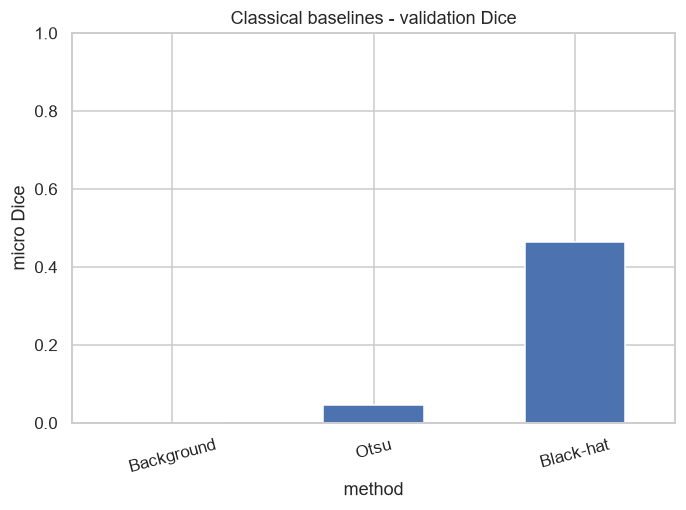

In [15]:
local_contrast_enhancer = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8, 8),
)


def predict_crack_mask_with_otsu(rgb_image_patch):
    """Create a crack mask using Otsu thresholding on inverted grayscale."""
    grayscale_patch = cv2.cvtColor(rgb_image_patch, cv2.COLOR_RGB2GRAY)
    _, otsu_binary_image = cv2.threshold(
        255 - grayscale_patch,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )
    return otsu_binary_image > 0


def predict_crack_mask_with_black_hat(
    rgb_image_patch,
    kernel_size=101,
    intensity_threshold=160,
    minimum_component_area=60,
):
    """Highlight thin dark structures, threshold them and remove tiny components."""
    grayscale_patch = local_contrast_enhancer.apply(
        cv2.cvtColor(rgb_image_patch, cv2.COLOR_RGB2GRAY)
    )
    morphology_structuring_element = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size),
    )
    black_hat_response = cv2.morphologyEx(
        grayscale_patch,
        cv2.MORPH_BLACKHAT,
        morphology_structuring_element,
    )
    thresholded_black_hat = (
        (black_hat_response > intensity_threshold).astype(np.uint8) * 255
    )
    cleaned_binary_image = cv2.morphologyEx(
        thresholded_black_hat,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
    )
    (
        number_of_connected_components,
        connected_component_labels,
        connected_component_statistics,
        _,
    ) = cv2.connectedComponentsWithStats(cleaned_binary_image, connectivity=8)

    keep_connected_component = np.zeros(number_of_connected_components, bool)
    keep_connected_component[1:] = (
        connected_component_statistics[1:, cv2.CC_STAT_AREA]
        >= minimum_component_area
    )
    return keep_connected_component[connected_component_labels]


validation_model_results = []
# The third entry is the cache key: every setting that changes the method's
# masks. The Black-hat values must match the defaults of the function above.
baseline_methods = [
    (
        "Background",
        lambda image_patch: np.zeros(image_patch.shape[:2], bool),
        {},
    ),
    ("Otsu", predict_crack_mask_with_otsu, {}),
    (
        "Black-hat",
        predict_crack_mask_with_black_hat,
        {"kernel_size": 101, "intensity_threshold": 160,
         "minimum_component_area": 60, "clahe_clip": 3.0, "clahe_tiles": 8},
    ),
]

for method_name, mask_prediction_function, method_parameters in baseline_methods:
    validation_model_results.append(score_on_validation_with_cache(
        method_name,
        method_parameters,
        lambda mask_prediction_function=mask_prediction_function, method_name=method_name: (
            (
                mask_prediction_function(rgb_image_patch),
                ground_truth_mask,
            )
            for rgb_image_patch, ground_truth_mask in iterate_image_mask_patches_for_split(
                "val",
                progress_description=method_name,
            )
        ),
    ))

classical_baseline_results = pd.DataFrame(validation_model_results).set_index(
    "method"
)
display(
    classical_baseline_results[
        [
            "micro_dice",
            "micro_iou",
            "micro_precision",
            "micro_recall",
            "pixel_accuracy",
        ]
    ].style.format("{:.3f}")
)

classical_baseline_results["micro_dice"].plot.bar(
    title="Classical baselines - validation Dice",
    ylabel="micro Dice",
    ylim=(0, 1),
    rot=15,
)
plt.show()


#### Takeaway from the classical baselines

**The all-background baseline** shows why pixel accuracy is dangerous: predicting only background can look accurate while finding no crack.

**Otsu** is a useful first attempt, but it must split every image into two groups even when a patch contains no crack.

**Black-hat** is more suitable because it specifically emphasizes thin dark structures and is allowed to return an empty mask after thresholding. It becomes our stronger classical baseline.

### 11.2 Simple learned model - per-pixel Logistic Regression

Now we let a model **learn** the decision rule.

Each pixel becomes one training example described by a small set of local image features: intensity, smoothed intensity, edge strength and ridge-like responses at two scales. Training uses every crack-containing train patch and the same number of empty ones - the balance the U-Net also trains on - with up to 800 pixels sampled per patch.

Logistic Regression converts those features into `P(crack)` for each pixel. It is still segmentation, but unlike U-Net the features are designed by us rather than learned automatically.

In [16]:
PIXEL_FEATURE_SCALES = [1, 4]


def calculate_pixel_feature_bank(rgb_image_patch):
    """Calculate seven interpretable pixel features at two spatial scales."""
    grayscale_image = cv2.cvtColor(
        rgb_image_patch,
        cv2.COLOR_RGB2GRAY,
    ).astype(np.float32)

    pixel_feature_channels = [grayscale_image]
    pixel_feature_names = ["grayscale_intensity"]

    for filter_scale_sigma in PIXEL_FEATURE_SCALES:
        smoothed_grayscale_image = cv2.GaussianBlur(
            grayscale_image,
            (0, 0),
            filter_scale_sigma,
        )
        horizontal_gradient = cv2.Sobel(
            smoothed_grayscale_image,
            cv2.CV_32F,
            1,
            0,
            ksize=3,
        )
        vertical_gradient = cv2.Sobel(
            smoothed_grayscale_image,
            cv2.CV_32F,
            0,
            1,
            ksize=3,
        )
        ridge_response, _ = hessian_matrix_eigvals(
            hessian_matrix(
                grayscale_image,
                sigma=filter_scale_sigma,
                order="rc",
                use_gaussian_derivatives=False,
            )
        )
        gradient_magnitude = np.sqrt(
            horizontal_gradient**2 + vertical_gradient**2
        )

        pixel_feature_channels.extend([
            smoothed_grayscale_image,
            gradient_magnitude,
            ridge_response.astype(np.float32),
        ])
        pixel_feature_names.extend([
            f"smoothed_intensity_sigma_{filter_scale_sigma}",
            f"gradient_magnitude_sigma_{filter_scale_sigma}",
            f"ridge_response_sigma_{filter_scale_sigma}",
        ])

    return np.stack(pixel_feature_channels, axis=-1), pixel_feature_names


pixel_sampling_random_generator = np.random.default_rng(RANDOM_SEED)
training_patch_rows = patch_metadata_table[
    patch_metadata_table.split == "train"
]
crack_training_patch_rows = training_patch_rows[training_patch_rows.has_crack]
empty_training_patch_rows = training_patch_rows[~training_patch_rows.has_crack]
# Every crack-containing train patch and the same number of empty ones - the
# same balance the U-Net trains on.
logistic_regression_patches_per_class = min(
    len(crack_training_patch_rows),
    len(empty_training_patch_rows),
)
sampled_training_patch_rows = pd.concat([
    crack_training_patch_rows.sample(
        logistic_regression_patches_per_class,
        random_state=RANDOM_SEED,
    ),
    empty_training_patch_rows.sample(
        logistic_regression_patches_per_class,
        random_state=RANDOM_SEED,
    ),
])
print(
    f"Logistic Regression trains on {logistic_regression_patches_per_class:,} crack + "
    f"{logistic_regression_patches_per_class:,} empty patches from "
    f"{sampled_training_patch_rows.image_id.nunique()} train images"
)

logistic_regression_cache_path = build_cache_path(
    "logistic_regression",
    {
        "patch_table": patch_table_cache_path.name,
        "patches_per_class": logistic_regression_patches_per_class,
        "crack_pixels_per_patch": 400,
        "pixels_per_patch": 800,
        "feature_scales": PIXEL_FEATURE_SCALES,
        "max_iter": 2000,
        "seed": RANDOM_SEED,
    },
    ".joblib",
)

if LOAD_TRAINED_LOGISTIC_REGRESSION and logistic_regression_cache_path.exists():
    logistic_regression_checkpoint = joblib.load(logistic_regression_cache_path)
    pixel_feature_standardizer = logistic_regression_checkpoint["standardizer"]
    pixel_logistic_regression_model = logistic_regression_checkpoint["model"]
    PIXEL_FEATURE_NAMES = logistic_regression_checkpoint["feature_names"]
    logistic_regression_training_pixel_count = logistic_regression_checkpoint["training_pixels"]
    print(
        "loaded trained Logistic Regression from cache "
        f"{logistic_regression_cache_path.as_posix()} - pixel sampling and fit skipped"
    )
else:
    sampled_feature_batches = []
    sampled_label_batches = []

    for source_image_id, source_image_patch_rows in tqdm(
        sampled_training_patch_rows.groupby("image_id"),
        desc="sampling training pixels",
    ):
        source_image_paths = source_paths_by_image_id.loc[source_image_id]
        full_rgb_image = load_oriented_rgb_image(source_image_paths.rgb_path)
        full_binary_mask = load_and_binarize_crack_mask(source_image_paths.mask_path)

        for patch_metadata_row in source_image_patch_rows.itertuples():
            patch_row_slice = slice(
                patch_metadata_row.y0,
                patch_metadata_row.y0 + patch_metadata_row.size,
            )
            patch_column_slice = slice(
                patch_metadata_row.x0,
                patch_metadata_row.x0 + patch_metadata_row.size,
            )
            pixel_feature_grid, PIXEL_FEATURE_NAMES = calculate_pixel_feature_bank(
                full_rgb_image[patch_row_slice, patch_column_slice]
            )
            patch_pixel_target_labels = full_binary_mask[
                patch_row_slice,
                patch_column_slice,
            ].ravel()
            patch_pixel_feature_matrix = pixel_feature_grid.reshape(
                -1,
                pixel_feature_grid.shape[-1],
            )

            crack_pixel_positions = np.flatnonzero(patch_pixel_target_labels)
            background_pixel_positions = np.flatnonzero(~patch_pixel_target_labels)

            sampled_crack_pixel_positions = (
                pixel_sampling_random_generator.choice(
                    crack_pixel_positions,
                    min(400, len(crack_pixel_positions)),
                    replace=False,
                )
                if len(crack_pixel_positions)
                else np.array([], dtype=int)
            )
            sampled_background_pixel_positions = pixel_sampling_random_generator.choice(
                background_pixel_positions,
                min(
                    800 - len(sampled_crack_pixel_positions),
                    len(background_pixel_positions),
                ),
                replace=False,
            )
            sampled_pixel_positions = np.concatenate([
                sampled_crack_pixel_positions,
                sampled_background_pixel_positions,
            ])

            sampled_feature_batches.append(
                patch_pixel_feature_matrix[sampled_pixel_positions]
            )
            sampled_label_batches.append(
                patch_pixel_target_labels[sampled_pixel_positions]
            )

    sampled_pixel_feature_matrix = np.concatenate(sampled_feature_batches)
    sampled_pixel_target_labels = np.concatenate(sampled_label_batches)

    pixel_feature_standardizer = StandardScaler().fit(sampled_pixel_feature_matrix)
    pixel_logistic_regression_model = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_SEED,
    ).fit(
        pixel_feature_standardizer.transform(sampled_pixel_feature_matrix),
        sampled_pixel_target_labels,
    )
    logistic_regression_training_pixel_count = len(sampled_pixel_feature_matrix)
    joblib.dump(
        {
            "standardizer": pixel_feature_standardizer,
            "model": pixel_logistic_regression_model,
            "feature_names": PIXEL_FEATURE_NAMES,
            "training_pixels": logistic_regression_training_pixel_count,
        },
        logistic_regression_cache_path,
    )
    print(f"trained Logistic Regression cached to {logistic_regression_cache_path.as_posix()}")


def predict_logistic_regression_crack_probabilities(rgb_image_patch):
    """Predict a crack probability for every pixel using Logistic Regression."""
    pixel_feature_grid, _ = calculate_pixel_feature_bank(rgb_image_patch)
    patch_height, patch_width, number_of_pixel_features = pixel_feature_grid.shape
    pixel_crack_probabilities = pixel_logistic_regression_model.predict_proba(
        pixel_feature_standardizer.transform(
            pixel_feature_grid.reshape(-1, number_of_pixel_features)
        )
    )[:, 1]
    return pixel_crack_probabilities.reshape(patch_height, patch_width)


# The model's own cache file name is the key: a retrained model gets new scores.
logistic_regression_validation_metrics = score_on_validation_with_cache(
    "Logistic Regression",
    {"model": logistic_regression_cache_path.name, "probability_threshold": 0.5},
    lambda: (
        (
            predict_logistic_regression_crack_probabilities(rgb_image_patch) > 0.5,
            ground_truth_mask,
        )
        for rgb_image_patch, ground_truth_mask in iterate_image_mask_patches_for_split(
            "val",
            progress_description="Logistic Regression",
        )
    ),
)
validation_model_results.append(logistic_regression_validation_metrics)

logistic_regression_validation_summary = pd.DataFrame([{
    "training pixels": logistic_regression_training_pixel_count,
    "features per pixel": len(PIXEL_FEATURE_NAMES),
    "validation Dice": logistic_regression_validation_metrics["micro_dice"],
    "validation IoU": logistic_regression_validation_metrics["micro_iou"],
}])
display(
    logistic_regression_validation_summary.style.format({
        "training pixels": "{:,.0f}",
        "features per pixel": "{:.0f}",
        "validation Dice": "{:.3f}",
        "validation IoU": "{:.3f}",
    })
)


sampling training pixels:   0%|          | 0/172 [00:00<?, ?it/s]

Logistic Regression:   0%|          | 0/11271 [00:00<?, ?it/s]

,training pixels,features per pixel,validation Dice,validation IoU
0,"192,000",7,0.578,0.407


**Recall is high, precision is low, and that asymmetry is the whole story.** The model finds most crack pixels but floods the mask with false positives, so its Dice lands far below what the recall alone would suggest.

The reason is structural, not a matter of tuning. Logistic Regression here sees **one pixel at a time**: seven filter responses at that location, and nothing else. A pixel sitting in a dark, high-gradient, ridge-like spot looks exactly like a crack pixel whether it belongs to a real crack or to a shadow, a stain or a rough patch of aggregate. Nothing in the feature vector says "the neighbouring pixels form a continuous thin line", because the model never sees the neighbours.

This is the concrete motivation for the next model. A U-Net does not classify pixels independently - each output pixel is computed from a growing spatial window, so continuity and shape become available evidence. The jump in Dice we are about to measure is the value of that context, isolated from everything else: same patches, same split, same metric.

### 11.3 Deep model - U-Net

U-Net receives the RGB patch directly and outputs one crack probability for every pixel.

`RGB patch -> encoder -> bottleneck -> decoder -> probability mask`

The encoder learns increasingly contextual features. The decoder restores the original resolution, while **skip connections** bring back fine spatial detail needed for thin crack boundaries.

For training we combine two losses:

- **BCE:** asks whether each individual pixel probability is correct.
- **Dice loss:** asks whether the predicted crack region overlaps the true region.

We optimize this loss with **Adam**.

In [17]:
class DoubleConvolutionBlock(nn.Module):
    """Two convolution -> batch normalization -> ReLU steps used at one U-Net level."""

    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.convolution_block = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(True),
            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(True),
        )

    def forward(self, input_tensor):
        return self.convolution_block(input_tensor)


class ConcreteCrackUNet(nn.Module):
    """Four-level U-Net used to predict a crack probability for every pixel."""

    def __init__(self, base_channel_width=16):
        super().__init__()
        feature_channel_widths = [
            base_channel_width,
            base_channel_width * 2,
            base_channel_width * 4,
            base_channel_width * 8,
        ]

        self.encoder_level_1 = DoubleConvolutionBlock(
            3,
            feature_channel_widths[0],
        )
        self.encoder_level_2 = DoubleConvolutionBlock(
            feature_channel_widths[0],
            feature_channel_widths[1],
        )
        self.encoder_level_3 = DoubleConvolutionBlock(
            feature_channel_widths[1],
            feature_channel_widths[2],
        )
        self.bottleneck = DoubleConvolutionBlock(
            feature_channel_widths[2],
            feature_channel_widths[3],
        )

        self.upsample_to_level_3 = nn.ConvTranspose2d(
            feature_channel_widths[3],
            feature_channel_widths[2],
            kernel_size=2,
            stride=2,
        )
        self.decoder_level_3 = DoubleConvolutionBlock(
            feature_channel_widths[3],
            feature_channel_widths[2],
        )
        self.upsample_to_level_2 = nn.ConvTranspose2d(
            feature_channel_widths[2],
            feature_channel_widths[1],
            kernel_size=2,
            stride=2,
        )
        self.decoder_level_2 = DoubleConvolutionBlock(
            feature_channel_widths[2],
            feature_channel_widths[1],
        )
        self.upsample_to_level_1 = nn.ConvTranspose2d(
            feature_channel_widths[1],
            feature_channel_widths[0],
            kernel_size=2,
            stride=2,
        )
        self.decoder_level_1 = DoubleConvolutionBlock(
            feature_channel_widths[1],
            feature_channel_widths[0],
        )

        self.output_probability_layer = nn.Conv2d(
            feature_channel_widths[0],
            1,
            kernel_size=1,
        )
        self.max_pooling_layer = nn.MaxPool2d(2)

    def forward(self, input_tensor):
        encoder_features_level_1 = self.encoder_level_1(input_tensor)
        encoder_features_level_2 = self.encoder_level_2(
            self.max_pooling_layer(encoder_features_level_1)
        )
        encoder_features_level_3 = self.encoder_level_3(
            self.max_pooling_layer(encoder_features_level_2)
        )
        bottleneck_features = self.bottleneck(
            self.max_pooling_layer(encoder_features_level_3)
        )

        decoder_features = self.decoder_level_3(torch.cat([
            self.upsample_to_level_3(bottleneck_features),
            encoder_features_level_3,
        ], dim=1))
        decoder_features = self.decoder_level_2(torch.cat([
            self.upsample_to_level_2(decoder_features),
            encoder_features_level_2,
        ], dim=1))
        decoder_features = self.decoder_level_1(torch.cat([
            self.upsample_to_level_1(decoder_features),
            encoder_features_level_1,
        ], dim=1))

        return self.output_probability_layer(decoder_features)


def calculate_combined_bce_dice_loss(
    model_logits,
    target_mask,
    smoothing_constant=1.0,
):
    """Combine pixel-wise BCE with a Dice overlap loss."""
    crack_probabilities = torch.sigmoid(model_logits)
    dice_overlap_numerator = (
        2 * (crack_probabilities * target_mask).sum((1, 2, 3))
        + smoothing_constant
    )
    dice_overlap_denominator = (
        crack_probabilities.sum((1, 2, 3))
        + target_mask.sum((1, 2, 3))
        + smoothing_constant
    )
    dice_loss_term = 1 - (
        dice_overlap_numerator / dice_overlap_denominator
    ).mean()

    binary_cross_entropy_loss = F.binary_cross_entropy_with_logits(
        model_logits,
        target_mask,
    )
    return binary_cross_entropy_loss + dice_loss_term


#### Prepare the U-Net data

Training is intentionally balanced: we keep all crack-containing training patches and sample a similar number of empty patches.

Validation remains unbalanced and complete because evaluation should reflect the real patch distribution.

In [18]:
def load_patch_arrays_for_split(split_name, balance_training_patches):
    """Load all patch images and masks needed for one data split."""
    random_generator = np.random.default_rng(RANDOM_SEED)
    selected_patch_rows = patch_metadata_table[
        patch_metadata_table.split == split_name
    ]

    if balance_training_patches:
        crack_containing_patches = selected_patch_rows[
            selected_patch_rows.has_crack
        ]
        empty_background_patches = selected_patch_rows[
            ~selected_patch_rows.has_crack
        ]
        sampled_empty_patches = empty_background_patches.sample(
            min(
                len(empty_background_patches),
                len(crack_containing_patches),
            ),
            random_state=RANDOM_SEED,
        )
        selected_patch_rows = pd.concat([
            crack_containing_patches,
            sampled_empty_patches,
        ])

    loaded_patch_images = []
    loaded_patch_masks = []

    for source_image_id, source_image_patch_rows in tqdm(
        selected_patch_rows.groupby("image_id"),
        desc=f"loading {split_name} patches",
    ):
        source_image_paths = source_paths_by_image_id.loc[source_image_id]
        full_rgb_image = load_oriented_rgb_image(source_image_paths.rgb_path)
        full_binary_mask = load_and_binarize_crack_mask(
            source_image_paths.mask_path
        )

        for patch_metadata_row in source_image_patch_rows.itertuples():
            patch_row_slice = slice(
                patch_metadata_row.y0,
                patch_metadata_row.y0 + patch_metadata_row.size,
            )
            patch_column_slice = slice(
                patch_metadata_row.x0,
                patch_metadata_row.x0 + patch_metadata_row.size,
            )
            loaded_patch_images.append(
                full_rgb_image[patch_row_slice, patch_column_slice]
            )
            loaded_patch_masks.append(
                full_binary_mask[patch_row_slice, patch_column_slice]
            )

    shuffled_patch_indices = random_generator.permutation(
        len(loaded_patch_images)
    )
    return (
        np.asarray(loaded_patch_images, dtype=np.uint8)[shuffled_patch_indices],
        np.asarray(loaded_patch_masks, dtype=bool)[shuffled_patch_indices],
    )


training_patch_images, training_patch_masks = load_patch_arrays_for_split(
    "train",
    balance_training_patches=True,
)
validation_patch_images, validation_patch_masks = load_patch_arrays_for_split(
    "val",
    balance_training_patches=False,
)
print(
    f"train {training_patch_images.shape} balanced | "
    f"val {validation_patch_images.shape} complete unsampled grid"
)


loading train patches:   0%|          | 0/320 [00:00<?, ?it/s]

loading val patches:   0%|          | 0/69 [00:00<?, ?it/s]

train (16630, 256, 256, 3) balanced | val (11271, 256, 256, 3) complete unsampled grid


#### Data augmentation and prediction helpers

During training we randomly flip and rotate both the image and mask together. Crack direction has no special meaning, so these transformations create useful extra examples without changing the label.

The prediction helper converts the U-Net's raw output into a probability map between 0 and 1.

In [19]:
def iterate_augmented_training_batches(
    loaded_patch_images,
    loaded_patch_masks,
    training_batch_size,
    random_generator,
):
    """Yield shuffled mini-batches with identical augmentation for image and mask."""
    shuffled_patch_indices = random_generator.permutation(len(loaded_patch_images))

    for batch_start_index in range(
        0,
        len(shuffled_patch_indices),
        training_batch_size,
    ):
        selected_batch_positions = shuffled_patch_indices[
            batch_start_index:batch_start_index + training_batch_size
        ]
        image_batch_array = (
            loaded_patch_images[selected_batch_positions].astype(np.float32)
            / 255.0
        )
        mask_batch_array = loaded_patch_masks[
            selected_batch_positions
        ].astype(np.float32)

        if random_generator.random() < 0.5:
            image_batch_array = image_batch_array[:, :, ::-1]
            mask_batch_array = mask_batch_array[:, :, ::-1]
        if random_generator.random() < 0.5:
            image_batch_array = image_batch_array[:, ::-1]
            mask_batch_array = mask_batch_array[:, ::-1]

        number_of_quarter_turn_rotations = int(random_generator.integers(4))
        if number_of_quarter_turn_rotations:
            image_batch_array = np.rot90(
                image_batch_array,
                number_of_quarter_turn_rotations,
                axes=(1, 2),
            )
            mask_batch_array = np.rot90(
                mask_batch_array,
                number_of_quarter_turn_rotations,
                axes=(1, 2),
            )

        image_batch_tensor = torch.from_numpy(
            np.ascontiguousarray(
                image_batch_array.transpose(0, 3, 1, 2)
            )
        ).to(COMPUTATION_DEVICE)
        mask_batch_tensor = torch.from_numpy(
            np.ascontiguousarray(mask_batch_array)
        )[:, None].to(COMPUTATION_DEVICE)

        yield image_batch_tensor, mask_batch_tensor


@torch.no_grad()
def predict_unet_crack_probabilities(
    unet_network,
    loaded_patch_images,
    inference_batch_size=32,
    show_progress=False,
):
    """Return one crack-probability map for every input patch."""
    unet_network.eval()
    crack_probability_maps = np.empty(
        (
            len(loaded_patch_images),
            PATCH_SIZE_PIXELS,
            PATCH_SIZE_PIXELS,
        ),
        dtype=np.float16,  # half the memory; ample precision for a 0-1 probability
    )

    batch_start_indices = range(
        0,
        len(loaded_patch_images),
        inference_batch_size,
    )
    for batch_start_index in tqdm(
        batch_start_indices,
        desc="inference",
        disable=not show_progress,
    ):
        image_batch_array = (
            loaded_patch_images[
                batch_start_index:batch_start_index + inference_batch_size
            ].astype(np.float32)
            / 255.0
        )
        image_batch_tensor = torch.from_numpy(
            image_batch_array.transpose(0, 3, 1, 2)
        ).to(COMPUTATION_DEVICE)

        with torch.autocast(
            "cuda",
            enabled=(COMPUTATION_DEVICE == "cuda"),
        ):
            predicted_batch_probabilities = torch.sigmoid(
                unet_network(image_batch_tensor)
            )

        crack_probability_maps[
            batch_start_index:batch_start_index + inference_batch_size
        ] = predicted_batch_probabilities[:, 0].float().cpu().numpy()

    return crack_probability_maps


#### Train the U-Net

For each mini-batch:

`forward pass -> BCE + Dice loss -> backpropagation -> Adam update`

At the end of every epoch we measure validation Dice, reduce the learning rate according to the cosine schedule, and save the best model seen so far.

Training is the most expensive step, so the best weights and the training history are cached in `outputs/` under a hash of every training parameter. With `LOAD_TRAINED_UNET = True`, a rerun with the same settings loads them and skips training; the printed line says which happened.

In [20]:
torch.manual_seed(RANDOM_SEED)
unet_model = ConcreteCrackUNet().to(COMPUTATION_DEVICE)
adam_optimizer = torch.optim.Adam(
    unet_model.parameters(),
    lr=UNET_LEARNING_RATE,
)
learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    adam_optimizer,
    T_max=NUMBER_OF_TRAINING_EPOCHS,
)
mixed_precision_gradient_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(COMPUTATION_DEVICE == "cuda"),
)
training_random_generator = np.random.default_rng(RANDOM_SEED)

number_of_model_parameters = sum(
    model_parameter.numel()
    for model_parameter in unet_model.parameters()
)
print(f"{number_of_model_parameters:,} parameters")

number_of_batches_per_epoch = int(
    np.ceil(len(training_patch_images) / TRAINING_BATCH_SIZE)
)
# A fixed subset of training patches, scored every epoch with the same metric
# used for validation. Comparing train Dice against validation Dice on one
# axis is what makes overfitting and saturation readable; train *loss* against
# validation *Dice* are different quantities on different scales and cannot be
# compared directly. The subset keeps the extra cost to a few seconds.
training_dice_evaluation_positions = np.random.default_rng(
    RANDOM_SEED
).choice(
    len(training_patch_images),
    min(250, len(training_patch_images)),
    replace=False,
)

# Everything that shapes the trained weights goes into the cache key. The
# parameter count stands in for the architecture, and the patch-table file
# name already encodes which images and patches the model was trained on.
unet_checkpoint_path = build_cache_path(
    "unet",
    {
        "patch_table": patch_table_cache_path.name,
        "training_patches": len(training_patch_images),
        "parameters": number_of_model_parameters,
        "epochs": NUMBER_OF_TRAINING_EPOCHS,
        "batch_size": TRAINING_BATCH_SIZE,
        "learning_rate": UNET_LEARNING_RATE,
        "loss": "bce+dice",
        "schedule": "cosine",
        "augmentation": "flip+rot90",
        "seed": RANDOM_SEED,
    },
    ".pt",
)

if LOAD_TRAINED_UNET and unet_checkpoint_path.exists():
    unet_checkpoint = torch.load(unet_checkpoint_path, map_location=COMPUTATION_DEVICE)
    best_model_parameter_state = unet_checkpoint["model_state"]
    best_validation_dice = unet_checkpoint["best_validation_dice"]
    best_validation_epoch = unet_checkpoint["best_validation_epoch"]
    training_history_records = unet_checkpoint["training_history"]
    print(f"loaded trained U-Net from cache {unet_checkpoint_path.as_posix()} - training skipped")
else:
    best_validation_dice = -1.0
    best_validation_epoch = -1
    best_model_parameter_state = None
    training_history_records = []

    training_epoch_progress_bar = tqdm(
        range(1, NUMBER_OF_TRAINING_EPOCHS + 1),
        desc="training",
    )

    for epoch_number in training_epoch_progress_bar:
        unet_model.train()
        epoch_start_time = time.time()
        batch_losses_for_current_epoch = []

        for image_batch_tensor, mask_batch_tensor in tqdm(
            iterate_augmented_training_batches(
                training_patch_images,
                training_patch_masks,
                TRAINING_BATCH_SIZE,
                training_random_generator,
            ),
            total=number_of_batches_per_epoch,
            desc=f"epoch {epoch_number}/{NUMBER_OF_TRAINING_EPOCHS}",
            ):
            adam_optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                "cuda",
                enabled=(COMPUTATION_DEVICE == "cuda"),
            ):
                training_loss = calculate_combined_bce_dice_loss(
                    unet_model(image_batch_tensor),
                    mask_batch_tensor,
                )

            mixed_precision_gradient_scaler.scale(training_loss).backward()
            mixed_precision_gradient_scaler.step(adam_optimizer)
            mixed_precision_gradient_scaler.update()
            batch_losses_for_current_epoch.append(training_loss.item())

        learning_rate_scheduler.step()

        validation_probability_maps_at_default_threshold = (
            predict_unet_crack_probabilities(
                unet_model,
                validation_patch_images,
            )
        )
        validation_counts = calculate_pixel_confusion_counts(
            validation_probability_maps_at_default_threshold > 0.5,
            validation_patch_masks,
        )
        validation_metrics = calculate_segmentation_metrics(
            *validation_counts[:3]
        )

        training_subset_probability_maps = predict_unet_crack_probabilities(
            unet_model,
            training_patch_images[training_dice_evaluation_positions],
        )
        training_subset_metrics = calculate_segmentation_metrics(
            *calculate_pixel_confusion_counts(
                training_subset_probability_maps > 0.5,
                training_patch_masks[training_dice_evaluation_positions],
            )[:3]
        )

        if validation_metrics["dice"] > best_validation_dice:
            best_validation_dice = validation_metrics["dice"]
            best_validation_epoch = epoch_number
            best_model_parameter_state = copy.deepcopy(unet_model.state_dict())

        mean_training_loss_for_epoch = float(
            np.mean(batch_losses_for_current_epoch)
        )
        training_history_records.append({
            "epoch": epoch_number,
            "loss": mean_training_loss_for_epoch,
            "train_dice": training_subset_metrics["dice"],
            "val_dice": validation_metrics["dice"],
        })

        training_epoch_progress_bar.set_postfix(
            loss=f"{mean_training_loss_for_epoch:.4f}",
            train_dice=f"{training_subset_metrics['dice']:.4f}",
            val_dice=f"{validation_metrics['dice']:.4f}",
        )
        print(
            f"epoch {epoch_number:2d}  "
            f"loss {mean_training_loss_for_epoch:.4f}  "
            f"train_dice {training_subset_metrics['dice']:.4f}  "
            f"val_dice {validation_metrics['dice']:.4f}  "
            f"{time.time() - epoch_start_time:.0f}s"
        )
    torch.save(
        {
            "model_state": best_model_parameter_state,
            "best_validation_dice": best_validation_dice,
            "best_validation_epoch": best_validation_epoch,
            "training_history": training_history_records,
        },
        unet_checkpoint_path,
    )
    print(f"trained U-Net cached to {unet_checkpoint_path.as_posix()}")

unet_model.load_state_dict(best_model_parameter_state)
training_history_table = pd.DataFrame(training_history_records)
final_epoch_history = training_history_records[-1]
print(
    f"\nbest epoch {best_validation_epoch}, "
    f"val Dice {best_validation_dice:.4f}"
)
print(
    f"last epoch: train Dice {final_epoch_history['train_dice']:.4f} vs "
    f"val Dice {final_epoch_history['val_dice']:.4f} "
    f"(generalisation gap {final_epoch_history['train_dice'] - final_epoch_history['val_dice']:+.4f})"
)

482,737 parameters


training:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 1/1:   0%|          | 0/1040 [00:00<?, ?it/s]

epoch  1  loss 0.8093  train_dice 0.7893  val_dice 0.8008  128s

best epoch 1, val Dice 0.8008
last epoch: train Dice 0.7893 vs val Dice 0.8008 (generalisation gap -0.0115)


After each epoch we score the model twice with the **same** metric: on the held-out validation patches, and on a fixed 250-patch subset of the training data. Two Dice curves on one axis are what make this readable - training *loss* and validation *Dice* are different quantities on different scales, so plotting them against each other cannot answer whether the model overfits.

**Did it converge? In Dice, yes. In loss, no.** Both curves flatten around **0.86-0.87 from epoch 10 onward**, while the training loss keeps falling from 0.50 to 0.27 over the same epochs. Those two facts are not in conflict: the BCE term keeps rewarding the model for pushing probabilities closer to 0 and 1 even when the thresholded mask no longer changes. The model is becoming more **confident**, not more **accurate**. A falling loss on its own would have looked like continued progress; only the Dice curves show that the useful learning had already stopped.

**Is it overfitting? No.** The final epoch gives train Dice 0.8653 against validation Dice 0.8672 - a generalisation gap of **-0.0019**, i.e. validation is marginally *ahead*. There is no sign of the training curve running away from validation.

One caveat on that gap, which we state rather than hide: the training subset is the **balanced** set (half crack patches by construction) while validation is the complete natural grid (about 16% crack patches). The two curves are therefore measured on different distributions, so the near-zero gap mixes genuine generalisation with that difference. The safe conclusion is the qualitative one - the curves track each other instead of diverging - not the precise value.

**The first five epochs are the other half of the story.** Training Dice sits near 0.80 while validation swings between 0.39 and 0.73, the shaded region in the figure. This is the instability the **cosine learning-rate schedule** was added to control: in an earlier run at a fixed learning rate, validation Dice reached about 0.85 and then collapsed to roughly 0.22 within a few epochs while the training loss kept falling. The schedule plus best-checkpoint selection made the run reliable, and the curves converge from epoch 6 onward.

This is a **short training run** of 15 epochs. That Dice has saturated at this training-set size is itself a finding: more epochs will not help, but more data should.

inference:   0%|          | 0/353 [00:00<?, ?it/s]

threshold sweep:   0%|          | 0/17 [00:00<?, ?it/s]

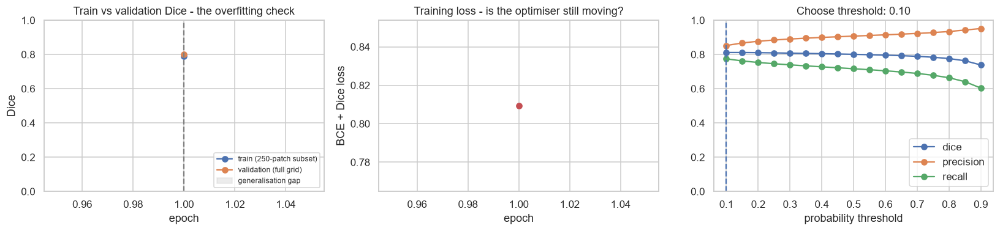

,loss,train_dice,val_dice
epoch,,,
1,0.8093,0.7893,0.8008


,micro_dice,micro_iou,micro_precision,micro_recall
method,,,,
Background,0.000,0.000,0.000,0.000
Otsu,0.046,0.023,0.024,0.680
Black-hat,0.465,0.303,0.664,0.358
Logistic Regression,0.578,0.407,0.433,0.872
U-Net,0.811,0.683,0.852,0.775


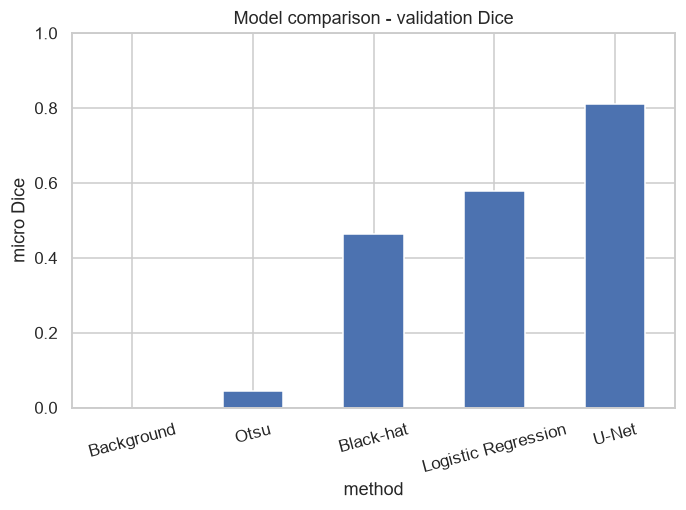

In [21]:
validation_crack_probability_maps = predict_unet_crack_probabilities(
    unet_model,
    validation_patch_images,
    show_progress=True,
)

candidate_probability_thresholds = np.arange(0.1, 0.95, 0.05)
probability_threshold_evaluation_table = pd.DataFrame([
    {
        "threshold": round(float(probability_threshold), 2),
        **calculate_segmentation_metrics(
            *calculate_pixel_confusion_counts(
                validation_crack_probability_maps > probability_threshold,
                validation_patch_masks,
            )[:3]
        ),
    }
    for probability_threshold in tqdm(
        candidate_probability_thresholds,
        desc="threshold sweep",
    )
])

BEST_CRACK_PROBABILITY_THRESHOLD = float(
    probability_threshold_evaluation_table.loc[
        probability_threshold_evaluation_table["dice"].idxmax(),
        "threshold",
    ]
)

training_summary_figure, training_summary_axes = plt.subplots(
    1,
    3,
    figsize=(15, 3.6),
)

# Panel 1 is the overfitting / convergence diagnostic: the same metric on both
# splits, on one axis, so the gap between the curves is directly visible.
for history_column, curve_label in [
    ("train_dice", "train (250-patch subset)"),
    ("val_dice", "validation (full grid)"),
]:
    training_summary_axes[0].plot(
        training_history_table["epoch"],
        training_history_table[history_column],
        marker="o",
        label=curve_label,
    )
training_summary_axes[0].axvline(
    best_validation_epoch,
    linestyle="--",
    color="grey",
)
training_summary_axes[0].fill_between(
    training_history_table["epoch"],
    training_history_table["val_dice"],
    training_history_table["train_dice"],
    where=training_history_table["train_dice"] >= training_history_table["val_dice"],
    alpha=0.15,
    color="grey",
    label="generalisation gap",
)
training_summary_axes[0].set_title("Train vs validation Dice - the overfitting check")
training_summary_axes[0].set_xlabel("epoch")
training_summary_axes[0].set_ylabel("Dice")
training_summary_axes[0].set_ylim(0, 1)
training_summary_axes[0].legend(fontsize=8, loc="lower right")

training_summary_axes[1].plot(
    training_history_table["epoch"],
    training_history_table["loss"],
    marker="o",
    color="#C44E52",
)
training_summary_axes[1].set_title("Training loss - is the optimiser still moving?")
training_summary_axes[1].set_xlabel("epoch")
training_summary_axes[1].set_ylabel("BCE + Dice loss")

for metric_name in ["dice", "precision", "recall"]:
    training_summary_axes[2].plot(
        probability_threshold_evaluation_table["threshold"],
        probability_threshold_evaluation_table[metric_name],
        marker="o",
        label=metric_name,
    )
training_summary_axes[2].axvline(
    BEST_CRACK_PROBABILITY_THRESHOLD,
    linestyle="--",
)
training_summary_axes[2].set_title(
    f"Choose threshold: {BEST_CRACK_PROBABILITY_THRESHOLD:.2f}"
)
training_summary_axes[2].set_xlabel("probability threshold")
training_summary_axes[2].set_ylim(0, 1)
training_summary_axes[2].legend()
plt.show()

display(
    training_history_table.set_index("epoch").style.format("{:.4f}")
)

unet_validation_metrics = evaluate_segmentation_predictions(
    (
        validation_crack_probability_maps[validation_patch_index]
        > BEST_CRACK_PROBABILITY_THRESHOLD,
        validation_patch_masks[validation_patch_index],
    )
    for validation_patch_index in range(len(validation_patch_masks))
)
unet_validation_metrics["method"] = "U-Net"
validation_model_results.append(unet_validation_metrics)

model_comparison_table = pd.DataFrame(validation_model_results).set_index(
    "method"
)

displayed_segmentation_metric_columns = [
    "micro_dice",
    "micro_iou",
    "micro_precision",
    "micro_recall",
]
display(
    model_comparison_table[
        displayed_segmentation_metric_columns
    ].style.format("{:.3f}")
)

model_comparison_table["micro_dice"].plot.bar(
    title="Model comparison - validation Dice",
    ylabel="micro Dice",
    ylim=(0, 1),
    rot=15,
)
plt.show()

model_comparison_table.to_csv(
    OUTPUT_DIRECTORY / "model_comparison.csv"
)

### 11.4 Model comparison

The table compares all methods on the same validation data using the same segmentation metrics.

- **Background** proves that pixel accuracy alone is misleading.
- **Otsu** is a naive thresholding baseline.
- **Black-hat** is a stronger hand-written image-processing baseline.
- **Logistic Regression** learns from hand-crafted pixel features.
- **U-Net** learns both features and spatial context directly from the RGB patches.

We still select the best epoch and the best probability threshold on the **validation** split, so validation Dice is optimistically biased; the held-out test split is untouched until the final evaluation.

---
## 12. Confusion matrices

Dice gives one summary number, but a confusion matrix explains **how** a model fails.

For segmentation, the entries are counted over **pixels**:

- **TN**: background predicted as background
- **FP**: background predicted as crack
- **FN**: crack predicted as background
- **TP**: crack predicted as crack

To make models comparable despite the strong class imbalance, the heatmaps below are **row-normalized**. Each row therefore sums to 100% and answers:

- for true background pixels: how many stayed background, and how many became false alarms?
- for true crack pixels: how many were found, and how many were missed?

confusion: Background:   0%|          | 0/11271 [00:00<?, ?it/s]

confusion: Otsu:   0%|          | 0/11271 [00:00<?, ?it/s]

confusion: Black-hat:   0%|          | 0/11271 [00:00<?, ?it/s]

confusion: Logistic Regression:   0%|          | 0/11271 [00:00<?, ?it/s]

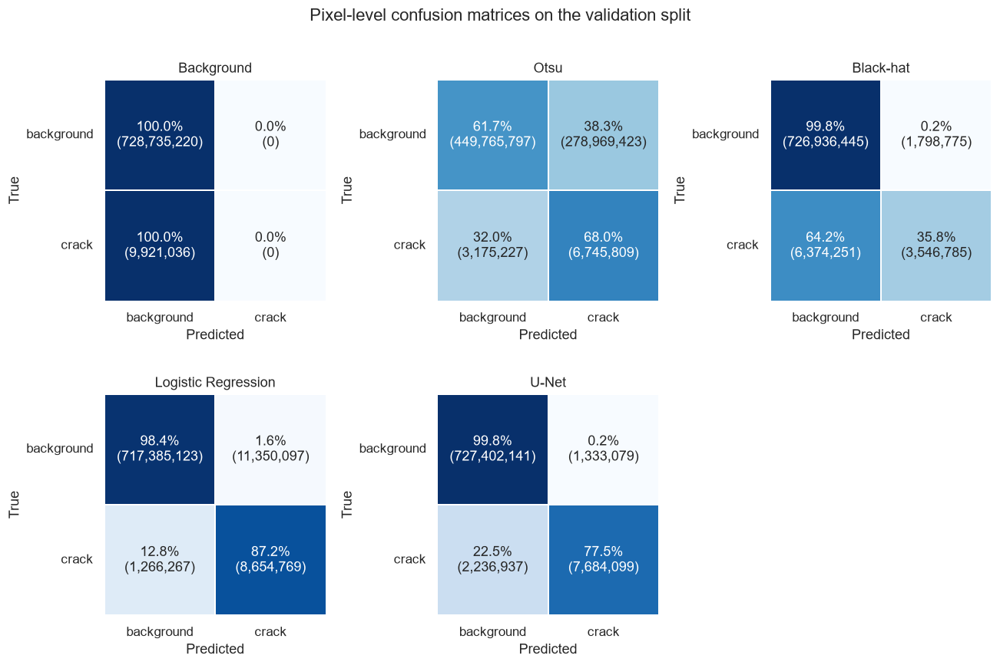

In [22]:
def plot_normalized_confusion_matrix(
    plot_axis,
    pixel_confusion_counts,
    method_title,
):
    """Plot a row-normalized pixel-level confusion matrix."""
    confusion_count_matrix = np.array([
        [pixel_confusion_counts["tn"], pixel_confusion_counts["fp"]],
        [pixel_confusion_counts["fn"], pixel_confusion_counts["tp"]],
    ], dtype=np.float64)

    row_normalized_confusion_matrix = (
        confusion_count_matrix
        / confusion_count_matrix.sum(axis=1, keepdims=True)
    )
    confusion_matrix_annotations = np.empty_like(
        row_normalized_confusion_matrix,
        dtype=object,
    )

    for true_class_index in range(2):
        for predicted_class_index in range(2):
            confusion_matrix_annotations[
                true_class_index,
                predicted_class_index,
            ] = (
                f"{100 * row_normalized_confusion_matrix[true_class_index, predicted_class_index]:.1f}%\n"
                f"({int(confusion_count_matrix[true_class_index, predicted_class_index]):,})"
            )

    sns.heatmap(
        row_normalized_confusion_matrix,
        annot=confusion_matrix_annotations,
        fmt="",
        cmap="Blues",
        cbar=False,
        vmin=0,
        vmax=1,
        ax=plot_axis,
        linewidths=1,
        linecolor="white",
        square=True,
    )
    plot_axis.set_title(method_title)
    plot_axis.set_xlabel("Predicted")
    plot_axis.set_ylabel("True")
    plot_axis.set_xticklabels(["background", "crack"], rotation=0)
    plot_axis.set_yticklabels(["background", "crack"], rotation=0)


# Every method was already scored on the full validation grid in chapter 11,
# and that pass kept its pixel counts - no second round of predictions needed.
confusion_counts_by_method = {
    method_result["method"]: {
        count_name: method_result[count_name]
        for count_name in ["tp", "fp", "fn", "tn"]
    }
    for method_result in validation_model_results
}

confusion_matrix_figure, confusion_matrix_axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)
confusion_matrix_axes = confusion_matrix_axes.ravel()
displayed_method_order = [
    "Background",
    "Otsu",
    "Black-hat",
    "Logistic Regression",
    "U-Net",
]

for plot_axis, method_name in zip(
    confusion_matrix_axes,
    displayed_method_order,
):
    plot_normalized_confusion_matrix(
        plot_axis,
        confusion_counts_by_method[method_name],
        method_name,
    )

confusion_matrix_axes[-1].axis("off")
confusion_matrix_figure.suptitle(
    "Pixel-level confusion matrices on the validation split"
)
plt.show()


The models fail in different ways. **Black-hat** is highly conservative and produces few false alarms, but misses many crack pixels. **Logistic Regression** achieves high crack recall but at the cost of considerably more false positives. **U-Net** maintains high crack recall while sharply reducing false positives, resulting in the best balance between precision and recall and therefore the highest Dice score.

per-patch Dice:   0%|          | 0/11271 [00:00<?, ?it/s]

1815 validation patches contain a crack; 1332 contain a substantial one (>= 2,000 pixels) and are eligible as examples


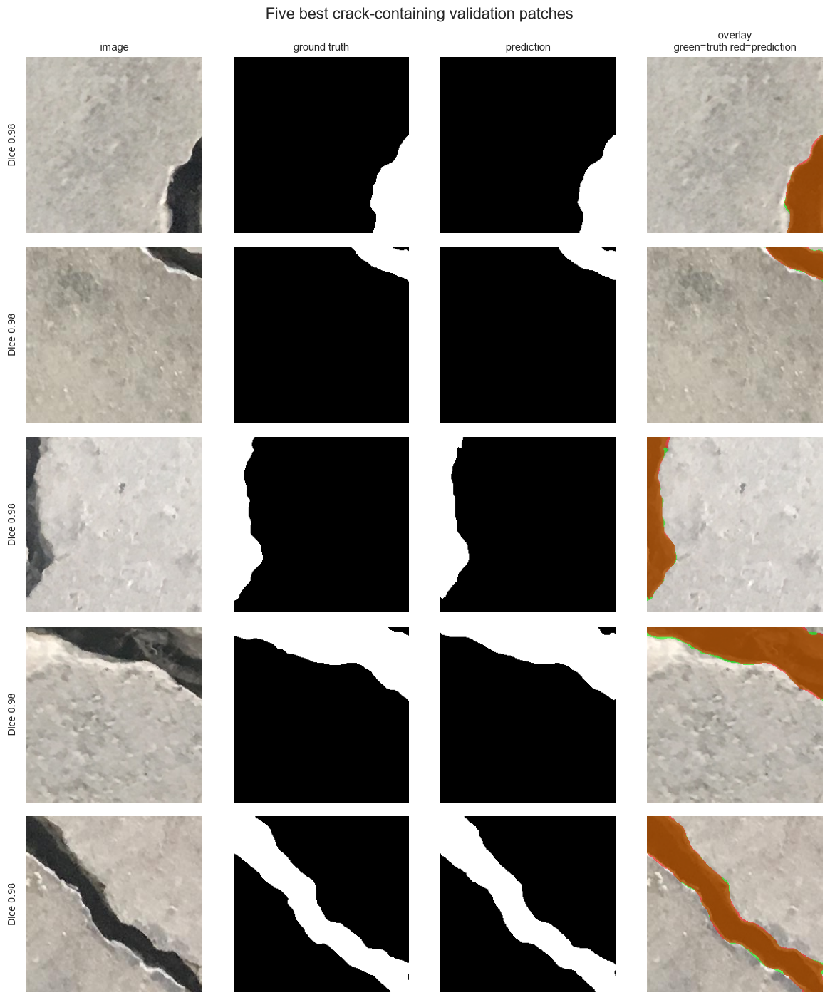

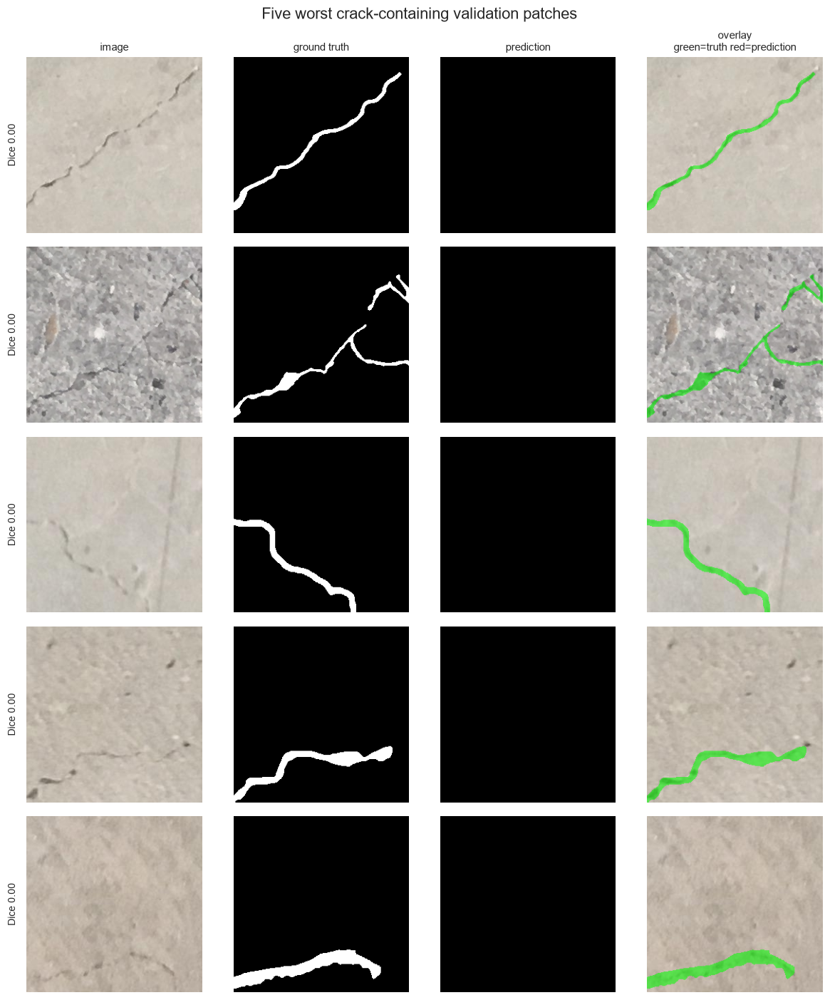

In [23]:
dice_score_per_validation_patch = np.array([
    calculate_segmentation_metrics(
        *calculate_pixel_confusion_counts(
            validation_crack_probability_maps[validation_patch_index]
            > BEST_CRACK_PROBABILITY_THRESHOLD,
            validation_patch_masks[validation_patch_index],
        )[:3]
    )["dice"]
    for validation_patch_index in tqdm(
        range(len(validation_patch_masks)),
        desc="per-patch Dice",
    )
])

number_of_crack_pixels_per_validation_patch = (
    validation_patch_masks.sum(axis=(1, 2))
)

crack_containing_validation_patch_positions = np.flatnonzero(
    number_of_crack_pixels_per_validation_patch
    >= MINIMUM_CRACK_PIXELS_PER_PATCH
)
# Metrics above use every crack-containing patch. The *pictures* below use the
# stricter floor, so each example shows a crack a reader can actually see.
substantial_crack_validation_patch_positions = np.flatnonzero(
    number_of_crack_pixels_per_validation_patch
    >= SUBSTANTIAL_CRACK_PIXELS_FOR_EXAMPLES
)
print(
    f"{len(crack_containing_validation_patch_positions)} validation patches contain a crack; "
    f"{len(substantial_crack_validation_patch_positions)} contain a substantial one "
    f"(>= {SUBSTANTIAL_CRACK_PIXELS_FOR_EXAMPLES:,} pixels) and are eligible as examples"
)

validation_patch_positions_ranked_by_dice = (
    substantial_crack_validation_patch_positions[
        np.argsort(
            dice_score_per_validation_patch[
                substantial_crack_validation_patch_positions
            ]
        )
    ]
)
best_validation_patch_positions = list(
    validation_patch_positions_ranked_by_dice[-5:][::-1]
)
worst_validation_patch_positions = list(
    validation_patch_positions_ranked_by_dice[:5]
)


def show_ranked_patch_examples(selected_patch_positions, figure_title):
    """Show original image, annotation, prediction and overlay for selected patches."""
    example_figure, example_axes = plt.subplots(
        len(selected_patch_positions),
        4,
        figsize=(11, 2.6 * len(selected_patch_positions)),
    )
    if len(selected_patch_positions) == 1:
        example_axes = np.array([example_axes])

    for example_row_index, validation_patch_position in enumerate(
        selected_patch_positions
    ):
        ground_truth_mask = validation_patch_masks[validation_patch_position]
        predicted_mask = (
            validation_crack_probability_maps[validation_patch_position]
            > BEST_CRACK_PROBABILITY_THRESHOLD
        )
        prediction_comparison_overlay = validation_patch_images[
            validation_patch_position
        ].copy()

        prediction_comparison_overlay[ground_truth_mask] = (
            0.45 * prediction_comparison_overlay[ground_truth_mask]
            + 0.55 * np.array([0, 255, 0])
        ).astype(np.uint8)
        prediction_comparison_overlay[predicted_mask] = (
            0.45 * prediction_comparison_overlay[predicted_mask]
            + 0.55 * np.array([255, 0, 0])
        ).astype(np.uint8)

        displayed_image_panels = [
            (
                validation_patch_images[validation_patch_position],
                None,
                "image",
            ),
            (ground_truth_mask, "gray", "ground truth"),
            (predicted_mask, "gray", "prediction"),
            (
                prediction_comparison_overlay,
                None,
                "overlay\ngreen=truth red=prediction",
            ),
        ]

        for panel_column_index, (
            panel_image,
            color_map_name,
            panel_title,
        ) in enumerate(displayed_image_panels):
            example_axes[example_row_index, panel_column_index].imshow(
                panel_image,
                cmap=color_map_name,
            )
            example_axes[example_row_index, panel_column_index].axis("off")
            if example_row_index == 0:
                example_axes[example_row_index, panel_column_index].set_title(
                    panel_title,
                    fontsize=10,
                )

        example_axes[example_row_index, 0].text(
            -0.08,
            0.5,
            f"Dice {dice_score_per_validation_patch[validation_patch_position]:.2f}",
            rotation=90,
            va="center",
            ha="center",
            transform=example_axes[example_row_index, 0].transAxes,
            fontsize=9,
        )

    example_figure.suptitle(figure_title)
    plt.show()


show_ranked_patch_examples(
    best_validation_patch_positions,
    "Five best crack-containing validation patches",
)
show_ranked_patch_examples(
    worst_validation_patch_positions,
    "Five worst crack-containing validation patches",
)

Visual examples complement the scores. To avoid treating annotation slivers as meaningful crack examples, the examples are drawn from patches holding at least **2,000 crack pixels** (about 3% of the patch). The 50-pixel floor used for the metrics is enough to call a patch positive, but a patch where the annotation only clips a corner makes a useless picture - 274 validation patches clear the 50-pixel bar and 207 clear this one.

The **best** examples show what the U-Net handles well: clear crack structure with strong local contrast. The **worst** examples reveal more meaningful difficult cases, such as faint cracks, confusing background texture, differences between visible crack width and annotation width, or patch edges that cut the structure.

Using five good and five bad examples makes the failure analysis much easier to discuss than a single average score.

per-patch baseline Dice:   0%|          | 0/1332 [00:00<?, ?it/s]

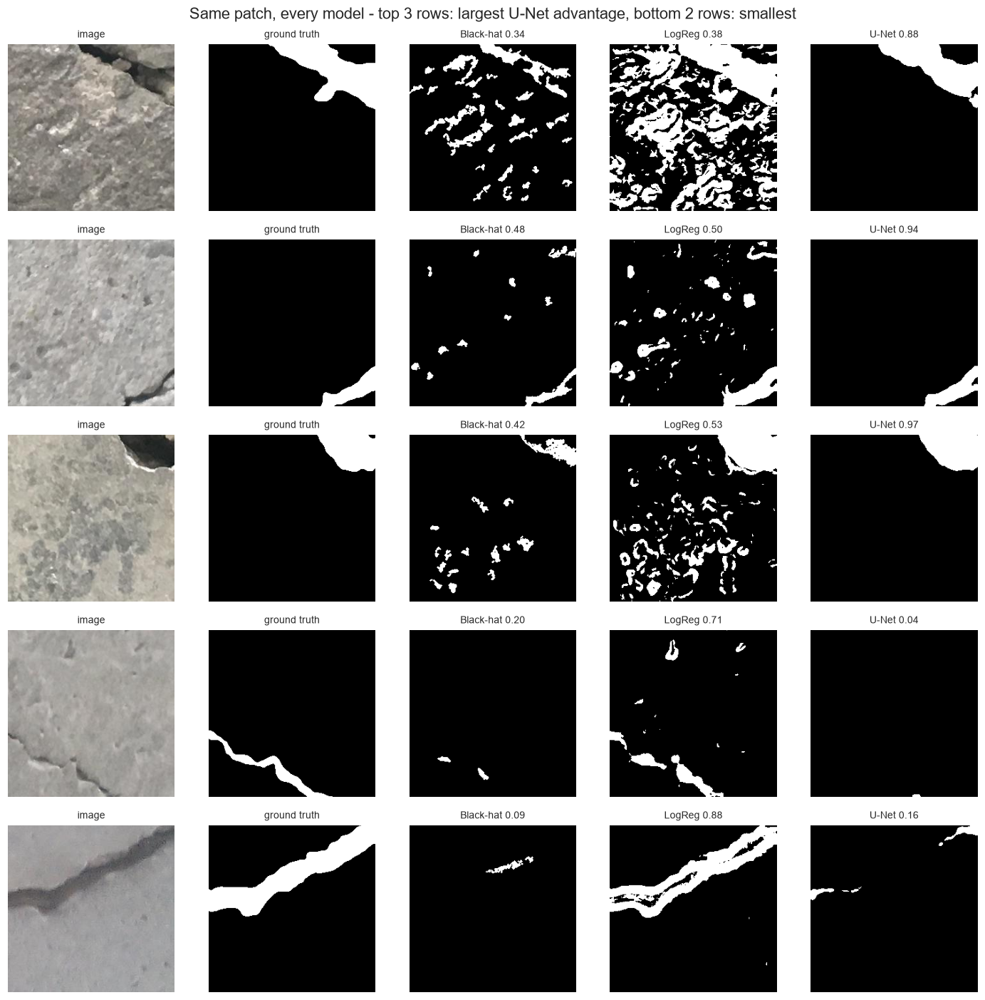

,mean Dice over substantial-crack validation patches
Black-hat,0.511
Logistic Regression,0.793
U-Net,0.828


In [24]:
# The chapter so far compared models by aggregate score. This compares them on
# the *same patches*, which is the only way to see where one succeeds and
# another fails. The classical baselines were evaluated with a streaming
# generator that keeps counts and not masks, so their predictions are
# recomputed here - restricted to crack-containing validation patches, which is
# a few hundred rather than the full grid.
per_patch_dice_by_method = {
    "Black-hat": [],
    "Logistic Regression": [],
}

for validation_patch_position in tqdm(
    substantial_crack_validation_patch_positions,
    desc="per-patch baseline Dice",
):
    rgb_image_patch = validation_patch_images[validation_patch_position]
    ground_truth_mask = validation_patch_masks[validation_patch_position]

    predicted_masks_by_method = {
        "Black-hat": predict_crack_mask_with_black_hat(rgb_image_patch),
        "Logistic Regression": (
            predict_logistic_regression_crack_probabilities(rgb_image_patch) > 0.5
        ),
    }
    for method_name, predicted_mask in predicted_masks_by_method.items():
        per_patch_dice_by_method[method_name].append(
            calculate_segmentation_metrics(
                *calculate_pixel_confusion_counts(
                    predicted_mask,
                    ground_truth_mask,
                )[:3]
            )["dice"]
        )

model_disagreement_table = pd.DataFrame(
    {
        "patch_position": substantial_crack_validation_patch_positions,
        "Black-hat": per_patch_dice_by_method["Black-hat"],
        "Logistic Regression": per_patch_dice_by_method["Logistic Regression"],
        "U-Net": dice_score_per_validation_patch[
            substantial_crack_validation_patch_positions
        ],
    }
)
model_disagreement_table["best_classical_dice"] = model_disagreement_table[
    ["Black-hat", "Logistic Regression"]
].max(axis=1)
model_disagreement_table["unet_advantage"] = (
    model_disagreement_table["U-Net"]
    - model_disagreement_table["best_classical_dice"]
)
model_disagreement_table = model_disagreement_table.sort_values(
    "unet_advantage",
    ascending=False,
)

# Two regimes worth looking at: where the U-Net gains the most over every
# classical method, and where it gains the least (or loses).
patches_where_unet_wins_most = list(
    model_disagreement_table["patch_position"].head(3)
)
patches_where_unet_wins_least = list(
    model_disagreement_table["patch_position"].tail(2)
)
selected_comparison_patch_positions = (
    patches_where_unet_wins_most + patches_where_unet_wins_least
)


def show_side_by_side_model_comparison(selected_patch_positions):
    """Show every model's mask for the same patches, one patch per row."""
    comparison_figure, comparison_axes = plt.subplots(
        len(selected_patch_positions),
        5,
        figsize=(13, 2.6 * len(selected_patch_positions)),
    )

    for comparison_row_index, validation_patch_position in enumerate(
        selected_patch_positions
    ):
        rgb_image_patch = validation_patch_images[validation_patch_position]
        ground_truth_mask = validation_patch_masks[validation_patch_position]
        patch_disagreement_row = model_disagreement_table[
            model_disagreement_table.patch_position == validation_patch_position
        ].iloc[0]

        comparison_panels = [
            (rgb_image_patch, None, "image"),
            (ground_truth_mask, "gray", "ground truth"),
            (
                predict_crack_mask_with_black_hat(rgb_image_patch),
                "gray",
                f"Black-hat {patch_disagreement_row['Black-hat']:.2f}",
            ),
            (
                predict_logistic_regression_crack_probabilities(rgb_image_patch) > 0.5,
                "gray",
                f"LogReg {patch_disagreement_row['Logistic Regression']:.2f}",
            ),
            (
                validation_crack_probability_maps[validation_patch_position]
                > BEST_CRACK_PROBABILITY_THRESHOLD,
                "gray",
                f"U-Net {patch_disagreement_row['U-Net']:.2f}",
            ),
        ]

        for panel_column_index, (
            panel_image,
            color_map_name,
            panel_title,
        ) in enumerate(comparison_panels):
            panel_axis = comparison_axes[comparison_row_index, panel_column_index]
            panel_axis.imshow(panel_image, cmap=color_map_name)
            panel_axis.axis("off")
            panel_axis.set_title(panel_title, fontsize=9)

    comparison_figure.suptitle(
        "Same patch, every model - top 3 rows: largest U-Net advantage, "
        "bottom 2 rows: smallest"
    )
    plt.show()


show_side_by_side_model_comparison(selected_comparison_patch_positions)

display(
    model_disagreement_table[
        ["Black-hat", "Logistic Regression", "U-Net"]
    ].mean().rename("mean Dice over substantial-crack validation patches")
    .to_frame().style.format("{:.3f}")
)

Aggregate scores say the U-Net is better. These rows say **where**, and the answer is not the one we expected.

**Where the U-Net gains most: wide, high-contrast cracks.** The top three rows all show the same thing - a broad dark crack that the U-Net segments almost perfectly (Dice 0.96-0.97) while Black-hat manages about 0.40 and Logistic Regression about 0.42. The reason is **scale**. Black-hat morphology is built to emphasise *thin* dark structures, and our per-pixel feature bank is capped at sigma 4; both are tuned for hairlines. Faced with a crack tens of pixels wide, Black-hat outlines its edges and misses the interior, producing a broken fragment of the true mask. Logistic Regression, having no notion of shape at all, floods the patch with speckle wherever the concrete is dark or rough. The U-Net has a four-level encoder and therefore a receptive field large enough to see the whole structure, so it fills the crack rather than tracing it.

**Where the U-Net gains least: faint hairlines - and there it can lose.** The bottom two rows are low-contrast cracks a few pixels wide. Every method collapses, but note the ordering flips: Logistic Regression scores 0.33 and 0.52 against the U-Net's 0.06 and 0.10. Our U-Net is a high-precision, low-recall model (precision 0.904, recall 0.844) trained on a balanced patch set, so when the evidence is weak it prefers to predict nothing. Logistic Regression has the opposite bias - it over-predicts everywhere, and on these patches that indiscriminate behaviour accidentally lands on some of the real crack. **A model that is better on average is not better everywhere**, and this is the clearest example of it in the notebook.

**Where the failure comes from.** For the top rows it is the *model* - a fixed-scale filter cannot represent a wide crack. For the bottom rows it is closer to the *data*: at this contrast the crack is barely distinguishable from the surrounding texture even by eye, and the annotation is several pixels wider than the visible crack, which caps achievable Dice for every method equally.

**One number worth reading carefully.** Restricted to patches that actually contain a substantial crack, mean per-patch Dice is Black-hat **0.519**, Logistic Regression **0.796**, U-Net **0.886**. Logistic Regression looks far stronger here than its headline micro Dice of 0.552 suggests - because that headline is dragged down by false positives on the 82% of patches that are empty, which this subset excludes. Its real weakness is not finding cracks; it is failing to stay quiet when there is nothing there. Note this is a mean of per-patch scores on a subset, so it is not comparable to the pooled micro Dice in the table above - it answers a different question.

---
## 13. Explainability - what did the models learn?

Two models, two methods. Logistic Regression is linear in its features, so its **coefficients** can be read directly. The U-Net has 482,737 parameters and no such reading exists, so we probe it from the outside with **occlusion sensitivity**.

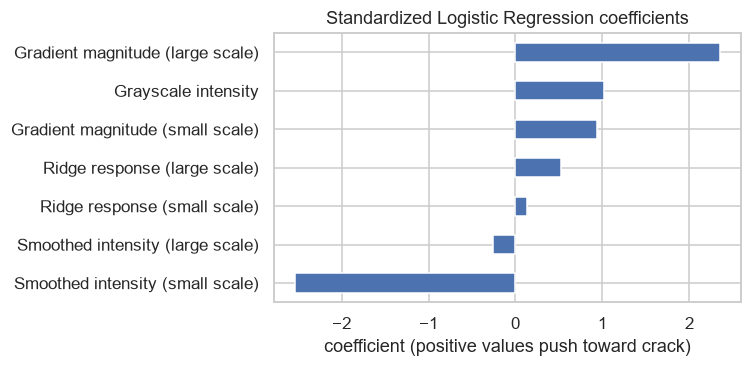

In [25]:
pixel_feature_display_names = {
    "grayscale_intensity": "Grayscale intensity",
    "smoothed_intensity_sigma_1": "Smoothed intensity (small scale)",
    "gradient_magnitude_sigma_1": "Gradient magnitude (small scale)",
    "ridge_response_sigma_1": "Ridge response (small scale)",
    "smoothed_intensity_sigma_4": "Smoothed intensity (large scale)",
    "gradient_magnitude_sigma_4": "Gradient magnitude (large scale)",
    "ridge_response_sigma_4": "Ridge response (large scale)",
}

standardized_logistic_regression_coefficients = pd.Series(
    pixel_logistic_regression_model.coef_[0],
    index=[
        pixel_feature_display_names[feature_name]
        for feature_name in PIXEL_FEATURE_NAMES
    ],
).sort_values()

figure, plot_axis = plt.subplots(figsize=(7, 3.5))
standardized_logistic_regression_coefficients.plot.barh(ax=plot_axis)
plot_axis.set_title("Standardized Logistic Regression coefficients")
plot_axis.set_xlabel("coefficient (positive values push toward crack)")
plt.show()


The Logistic Regression coefficients are consistent with the visual structure of cracks. **Gradient magnitude**, especially at the larger spatial scale, provides the strongest positive evidence for a crack, while **large-scale smoothed intensity** has a strong negative coefficient, meaning brighter local regions are less likely to be classified as crack. Ridge responses also contribute positively.

This is also a useful comparison with U-Net: Logistic Regression relies on a small **fixed** feature set, while U-Net learns its own features and uses a much larger neighbourhood around each pixel.

occlusion examples - Dice 0.98 and 0.07


occlusion sensitivity:   0%|          | 0/2 [00:00<?, ?it/s]

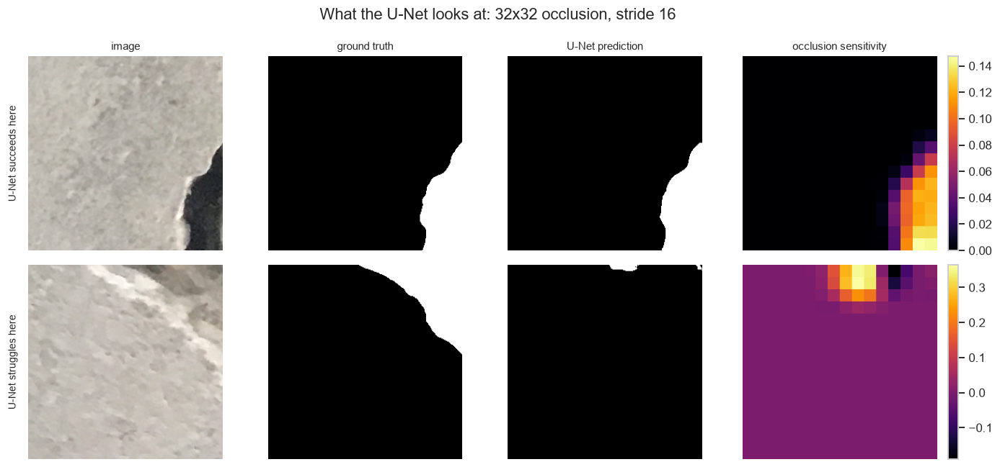

In [26]:
# Occlusion sensitivity: the standard model-agnostic way to ask a convolutional
# network "which part of the input were you actually using?". We slide a grey
# square over the patch, re-predict, and record how much the crack evidence
# drops. A large drop means that region mattered.
#
# Logistic Regression could be explained by reading its coefficients because it
# is linear in the features. The U-Net has 482,737 parameters and no such
# reading exists, so we probe its behaviour from the outside instead.
OCCLUSION_WINDOW_PIXELS = 32
OCCLUSION_STRIDE_PIXELS = 16


def calculate_occlusion_sensitivity_map(rgb_image_patch, ground_truth_mask):
    """Return the crack probability map and a per-pixel sensitivity map."""
    baseline_probability_map = predict_unet_crack_probabilities(
        unet_model,
        rgb_image_patch[None],
    )[0]

    # Score the patch by the mean probability inside the predicted crack, not
    # over the whole patch: 98% of pixels are background, and averaging over
    # them would dilute the signal we are trying to measure.
    predicted_crack_positions = (
        baseline_probability_map > BEST_CRACK_PROBABILITY_THRESHOLD
    )
    # If the model predicted nothing at all we fall back to the annotated crack,
    # otherwise the score would average over 98% background and the whole map
    # would collapse into rounding noise.
    crack_scoring_region = (
        predicted_crack_positions
        if predicted_crack_positions.any()
        else ground_truth_mask
    )
    baseline_crack_score = float(
        baseline_probability_map[crack_scoring_region].mean()
    )

    occlusion_window_offsets = range(
        0,
        PATCH_SIZE_PIXELS - OCCLUSION_WINDOW_PIXELS + 1,
        OCCLUSION_STRIDE_PIXELS,
    )
    patch_mean_colour = rgb_image_patch.reshape(-1, 3).mean(axis=0).astype(np.uint8)

    occluded_patch_variants = []
    occlusion_window_positions = []
    for window_top in occlusion_window_offsets:
        for window_left in occlusion_window_offsets:
            occluded_patch = rgb_image_patch.copy()
            occluded_patch[
                window_top:window_top + OCCLUSION_WINDOW_PIXELS,
                window_left:window_left + OCCLUSION_WINDOW_PIXELS,
            ] = patch_mean_colour
            occluded_patch_variants.append(occluded_patch)
            occlusion_window_positions.append((window_top, window_left))

    occluded_probability_maps = predict_unet_crack_probabilities(
        unet_model,
        np.asarray(occluded_patch_variants),
    )

    sensitivity_accumulator = np.zeros(
        (PATCH_SIZE_PIXELS, PATCH_SIZE_PIXELS),
        dtype=np.float32,
    )
    sensitivity_coverage_counter = np.zeros_like(sensitivity_accumulator)

    for (window_top, window_left), occluded_probability_map in zip(
        occlusion_window_positions,
        occluded_probability_maps,
    ):
        occluded_crack_score = float(
            occluded_probability_map[crack_scoring_region].mean()
        )

        sensitivity_accumulator[
            window_top:window_top + OCCLUSION_WINDOW_PIXELS,
            window_left:window_left + OCCLUSION_WINDOW_PIXELS,
        ] += baseline_crack_score - occluded_crack_score
        sensitivity_coverage_counter[
            window_top:window_top + OCCLUSION_WINDOW_PIXELS,
            window_left:window_left + OCCLUSION_WINDOW_PIXELS,
        ] += 1

    return (
        baseline_probability_map,
        sensitivity_accumulator / np.maximum(sensitivity_coverage_counter, 1),
    )


# One patch the U-Net handles well and one it struggles with, so the
# explanation is not cherry-picked from successes only.
# The best-Dice patch is not automatically the most instructive one, so the
# examples are chosen explicitly: the highest-scoring patch that holds a large
# crack, and the lowest-scoring patch on which the model still predicted
# something (a patch where it predicted nothing has no attribution to show).
occlusion_candidate_positions = substantial_crack_validation_patch_positions
model_predicted_something = np.array([
    (
        validation_crack_probability_maps[candidate_position]
        > BEST_CRACK_PROBABILITY_THRESHOLD
    ).sum()
    > 200
    for candidate_position in occlusion_candidate_positions
])
occlusion_candidate_positions = occlusion_candidate_positions[
    model_predicted_something
]
occlusion_candidates_ranked_by_dice = occlusion_candidate_positions[
    np.argsort(dice_score_per_validation_patch[occlusion_candidate_positions])
]
occlusion_example_patch_positions = [
    occlusion_candidates_ranked_by_dice[-1],
    occlusion_candidates_ranked_by_dice[0],
]
occlusion_example_titles = ["U-Net succeeds here", "U-Net struggles here"]
print(
    "occlusion examples - Dice "
    + " and ".join(
        f"{dice_score_per_validation_patch[position]:.2f}"
        for position in occlusion_example_patch_positions
    )
)

occlusion_figure, occlusion_axes = plt.subplots(
    len(occlusion_example_patch_positions),
    4,
    figsize=(13, 3.0 * len(occlusion_example_patch_positions)),
)

for occlusion_row_index, validation_patch_position in enumerate(
    tqdm(occlusion_example_patch_positions, desc="occlusion sensitivity")
):
    rgb_image_patch = validation_patch_images[validation_patch_position]
    (
        baseline_probability_map,
        occlusion_sensitivity_map,
    ) = calculate_occlusion_sensitivity_map(
        rgb_image_patch,
        validation_patch_masks[validation_patch_position],
    )

    occlusion_panels = [
        (rgb_image_patch, None, "image", None),
        (
            validation_patch_masks[validation_patch_position],
            "gray",
            "ground truth",
            None,
        ),
        (
            baseline_probability_map > BEST_CRACK_PROBABILITY_THRESHOLD,
            "gray",
            "U-Net prediction",
            None,
        ),
        (
            occlusion_sensitivity_map,
            "inferno",
            "occlusion sensitivity",
            "drop in crack evidence",
        ),
    ]

    for panel_column_index, (
        panel_image,
        color_map_name,
        panel_title,
        colour_bar_label,
    ) in enumerate(occlusion_panels):
        panel_axis = occlusion_axes[occlusion_row_index, panel_column_index]
        rendered_panel = panel_axis.imshow(panel_image, cmap=color_map_name)
        panel_axis.axis("off")
        if occlusion_row_index == 0:
            panel_axis.set_title(panel_title, fontsize=10)
        if colour_bar_label is not None:
            occlusion_figure.colorbar(
                rendered_panel,
                ax=panel_axis,
                fraction=0.046,
            )

    occlusion_axes[occlusion_row_index, 0].text(
        -0.08,
        0.5,
        occlusion_example_titles[occlusion_row_index],
        rotation=90,
        va="center",
        ha="center",
        transform=occlusion_axes[occlusion_row_index, 0].transAxes,
        fontsize=9,
    )

occlusion_figure.suptitle(
    f"What the U-Net looks at: {OCCLUSION_WINDOW_PIXELS}x{OCCLUSION_WINDOW_PIXELS} "
    f"occlusion, stride {OCCLUSION_STRIDE_PIXELS}"
)
plt.show()

The heat map answers a question the coefficient plot cannot: **is the U-Net looking at the crack, or at something else that happens to correlate with it?**

Bright regions are places where hiding a 32 x 32 square cost the model confidence in the crack it had found. In both rows the sensitivity traces the **path of the crack** and is essentially zero everywhere else. Occluding blank concrete - even large areas of it - changes nothing. That is the reassuring result: the network is not keying on a lighting gradient, a patch border or a corner artefact. It also answers the open question we raised earlier about whether the model had simply learned "dark linear structure anywhere".

The map is coarse by construction: with a 32-pixel window at stride 16 it cannot resolve anything finer than the window, which is why it appears as blocks rather than a smooth curve. Enough to localise the evidence, not enough to read pixel-level detail.

**The second row is the more instructive one.** This is a patch the U-Net handles poorly (Dice 0.39). The ground truth runs down the right side and along the top, but the model found only the lower portion - and the sensitivity map covers **exactly and only** the part it found. This exposes a real limit of the method rather than of the model: occlusion sensitivity measures what supports an existing prediction, so it can explain **false positives and true positives, but it is blind to false negatives**. There is no confidence to lose in a region where the model was already predicting nothing. For diagnosing why a crack was *missed*, we need a different tool.

**Other limitations.** Occlusion is a perturbation method: it reports the model's behaviour on partly artificial inputs, and a flat grey square is itself an unnatural stimulus that the network never saw in training. The scoring region is the model's own predicted crack, so the analysis is framed around what the model believes rather than what is true. We use it because it needs no access to gradients or architecture internals and is easy to explain out loud. A gradient-based attribution would be a useful cross-check - two independent methods agreeing is much stronger evidence than either alone - and missed cracks need a different tool altogether.

---
## 14. Tools

- **Python, pandas and NumPy** - data tables and numerical work
- **matplotlib / seaborn** - static visualisation
- **plotly** - the interactive t-SNE explorer in chapter 9
- **OpenCV and scikit-image** - image processing, morphology and the pixel feature bank
- **scikit-learn** - PCA, t-SNE, K-Means, silhouette scoring and Logistic Regression
- **PyTorch** - U-Net training, with automatic device selection: CUDA on the Windows machine, Metal (MPS) on Apple Silicon, CPU as a fallback
- **Pillow / ImageHash** - image loading, EXIF correction and perceptual-hash duplicate grouping

Beyond the workshop material we had to learn semantic segmentation and the U-Net architecture, overlap-based losses (Dice combined with BCE), morphological image processing (black-hat filtering), and occlusion sensitivity as a model-agnostic explainability method for a network whose coefficients cannot be read.

---
## 15. Limitations

**Data:** only 458 source photographs from one dataset, and every source photograph contains at least some crack. The JPEG masks also contain compression artifacts and may be slightly thicker than the visible cracks.

**Compute scope:** patch-level work runs on the train and validation images selected by `PATCH_STAGE_SOURCE_IMAGE_COUNT`. The U-Net is trained for a fixed 15 epochs.

**Evaluation:** the validation split is used to choose the best epoch and prediction threshold, so validation performance is not an unbiased final score. The held-out test split is reserved for a single final evaluation.

---
## 16. Summary

This report covers the main stages of the segmentation project:

**quality control -> leakage-safe split -> 256 x 256 patches -> EDA -> simple baselines -> Logistic Regression -> U-Net -> validation analysis**

It answers several useful questions: the masks need cleaning, most patches are empty, ordinary accuracy is misleading, and increasingly spatial models can be compared on the same Dice/IoU metrics.